In [1]:
from erebus.individual_fit_results import IndividualFitResults
from erebus.joint_fit_results import JointFitResults
import numpy as np
import os
from uncertainties import ufloat
import yaml
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import cm
from matplotlib import colors as colours
from scipy.stats import norm
from erebus.utility.utils import bin_data
from erebus.utility.utils import get_eclipse_duration
from erebus.photometry_data import PhotometryData
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from astropy.time import Time
from erebus.systematics.frame_normalized_pca import perform_fn_pca_on_aperture
from scipy.optimize import curve_fit
from uncertainties import ufloat

plt.rcParams.update(plt.rcParamsDefault)

plt.rcParams.update({
	#'font.family': 'serif',
    #'font.serif': ['cmr10'],
    #'mathtext.fontset': 'cm',
    'axes.formatter.use_mathtext': True,    
	'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.0,
    'figure.dpi': 300,
})

single_column = (3.5, 2.625)
double_column = (7, 5.25)

def get_eclipse_duration_from_res(visit):
	return get_eclipse_duration(
		visit.results['inc'].nominal_value,
		visit.results['a_rstar'].nominal_value,
		visit.results['rp_rstar'].nominal_value,
		visit.results['p'].nominal_value
	) * 24

In [2]:
import spelunker
import numpy as np
import matplotlib.pyplot as plt
mast_api_token = str(np.loadtxt('MAST Token.txt', dtype=str))

In [3]:
# Load the individual results
visit_fits_files = glob("./FNPCA 5px final/*visit*.h5")
visit_fits = [IndividualFitResults.load(v) for v in visit_fits_files]

visit_fits = sorted(visit_fits, key=lambda x: x.visit_name)

# Load the photometry data
phot_files = glob("./Raw photometry/*.h5")
phot_data = [PhotometryData.load(f) for f in phot_files] 

# Correcting phot data for visit 4 (this is also done by the pipeline before fitting)
cutoff = np.where(phot_data[4].raw_flux < 0.995)[0][0]
phot_data[4].raw_flux[:cutoff] /= np.median(phot_data[4].raw_flux[:cutoff])
phot_data[4].raw_flux[cutoff:] /= np.median(phot_data[4].raw_flux[cutoff:])

2026-05-24 20:08:55,383 - stpipe - WARNING - /home/nicho/.local/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")



1.35+/-0.04
-0.215+/-0.030
-0.284+/-0.031
-0.384+/-0.030


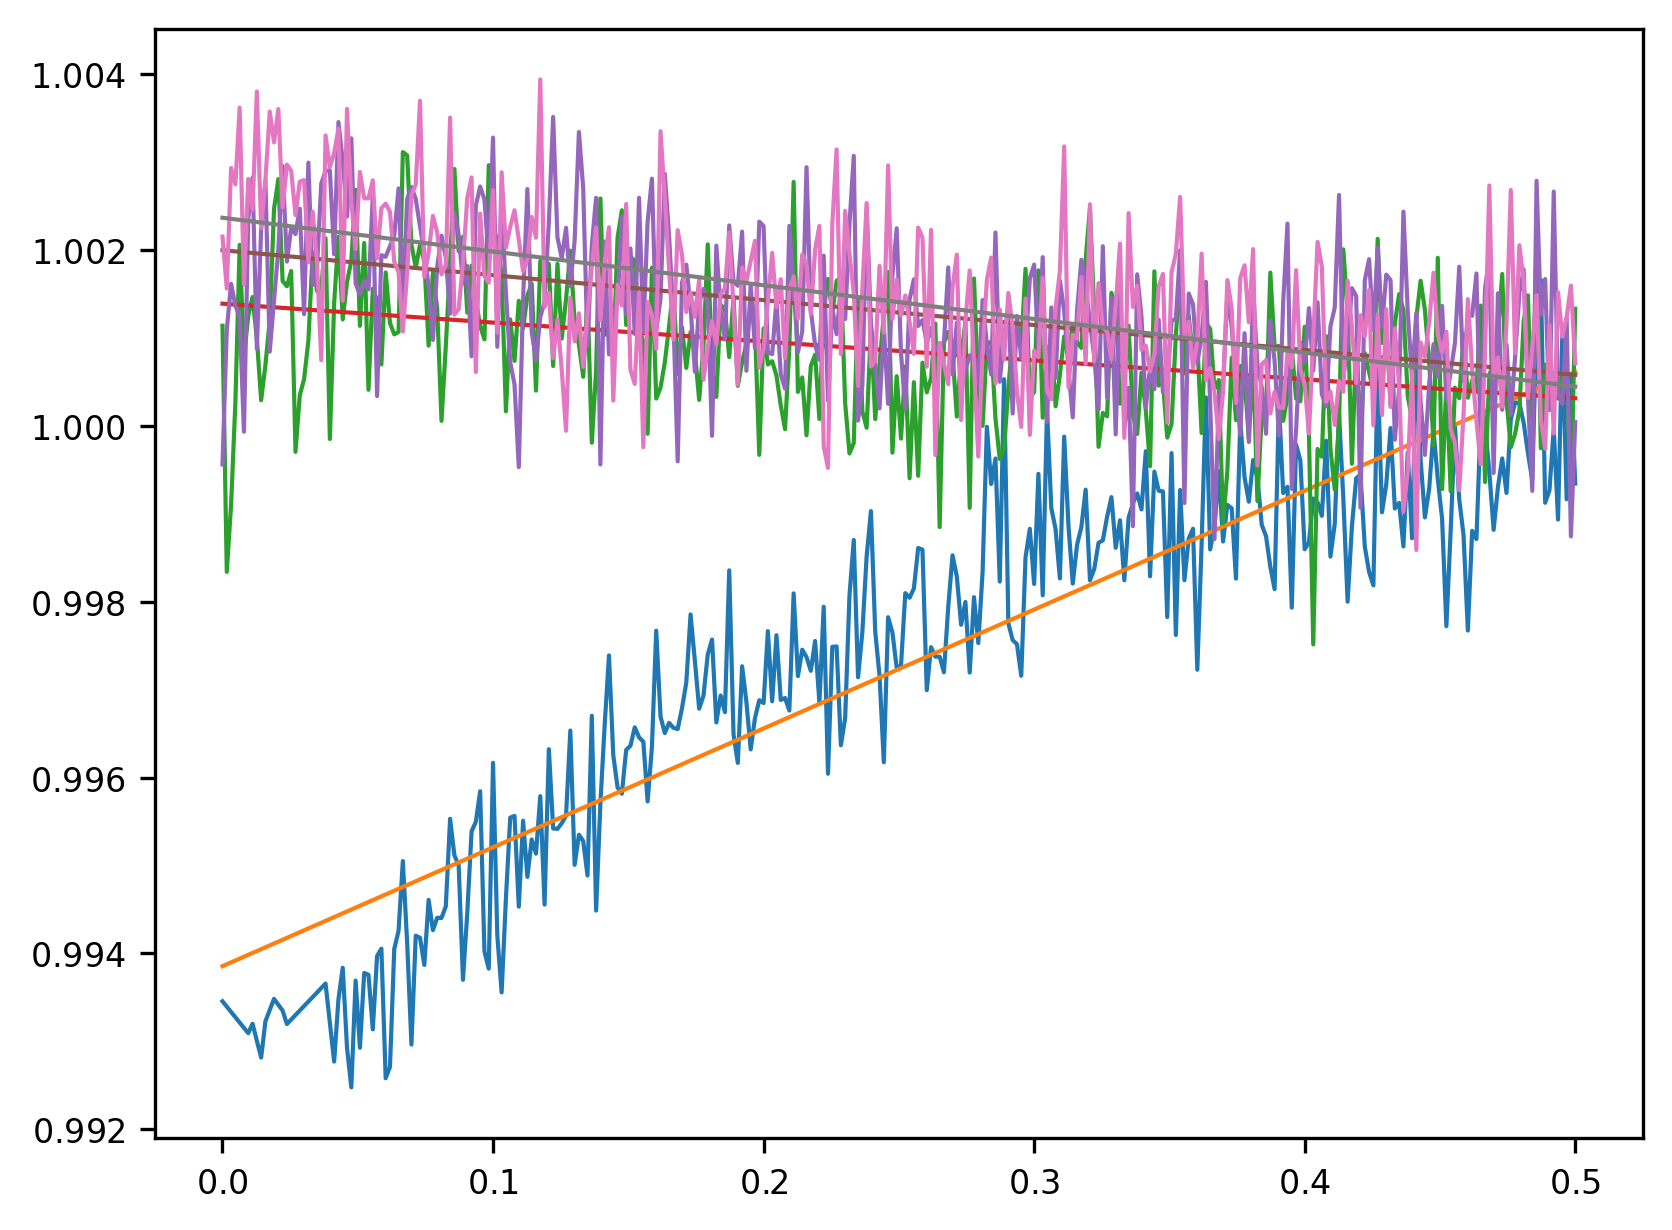

In [4]:
from uncertainties import ufloat
from scipy.optimize import curve_fit

def linear(x, m, b):
	return m * x + b

def fit_slope(data):
	y = data.raw_flux
	x = (data.time - np.min(data.time)) * 24 # hour
	
	inds = np.where(x < 0.5) # 30 min

	#x = np.arange(len(data.time)) # integrations

	popt, pcov = curve_fit(linear, x[inds], y[inds])

	m, b = popt
	m_err = np.sqrt(pcov[0, 0])

	m, b = np.polyfit(x[inds], y[inds], 1)
	y_model = m * x[inds] + b
	
	plt.plot(x[inds], y[inds])
	plt.plot(x[inds], y_model)
	
	diff = ufloat(m, m_err) * 1e2 # Change in % over 0.5 hr
	print(diff)
	return diff

gj3929b_visit1_slope = fit_slope(phot_data[0])
gj3929b_visit2_slope = fit_slope(phot_data[1])
gj3929b_visit3_slope = fit_slope(phot_data[2])
gj3929b_visit4_slope = fit_slope(phot_data[3])

In [5]:
hot_rocks_ids = [1, 2, 4, 14, 15, 19, 20, 21, 22, 29]
l231 = [19, 20, 21, 22]
ltt = [14, 15]
gj = [1, 2, 4, 29]

In [6]:
def get_p750L(pid, visit):
	spk = spelunker.load()
	try:
		spk.readfile(pid=pid, obs_num=visit)
	except:
		spk = spelunker.load(pid=pid, obs_num=visit)

	spk.mast_api_token = mast_api_token

	t_start = spk.fg_time[0]
	t_end = t_start + 1/24 # hours
	plt.close()
	ax0 = spk.mnemonics('IMIR_HK_FW_CUR_POS', t_start, t_end)
	
	line = ax0.lines[0]
	x_data = line.get_xdata()
	y_data = line.get_ydata()
	plt.title(visit)
	plt.show()
	
	prev_filter = x_data[np.where(y_data == 'P750L')]
	if len(prev_filter) == 0:
		print(f"Visit {visit} was not on P750L")
		return 0
	duration = (prev_filter.max() - prev_filter.min()) * 24 * 60
	print(f"{duration:0.2f} minutes")
	return duration

Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730001001_gs-fg_2024072145901-seg001/jw03730001001_gs-fg_2024072145901-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730001001_gs-fg_2024072145901-seg002/jw03730001001_gs-fg_2024072145901-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730001001_gs-fg_2024072145901-seg003/jw03730001001_gs-fg_2024072145901-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730001001_gs-fg_2024072145901-seg004/jw03730001001_gs-fg_2024072145901-seg004_cal.fits']
                    filenames                    
-------------------------------------------------
jw03730001001_

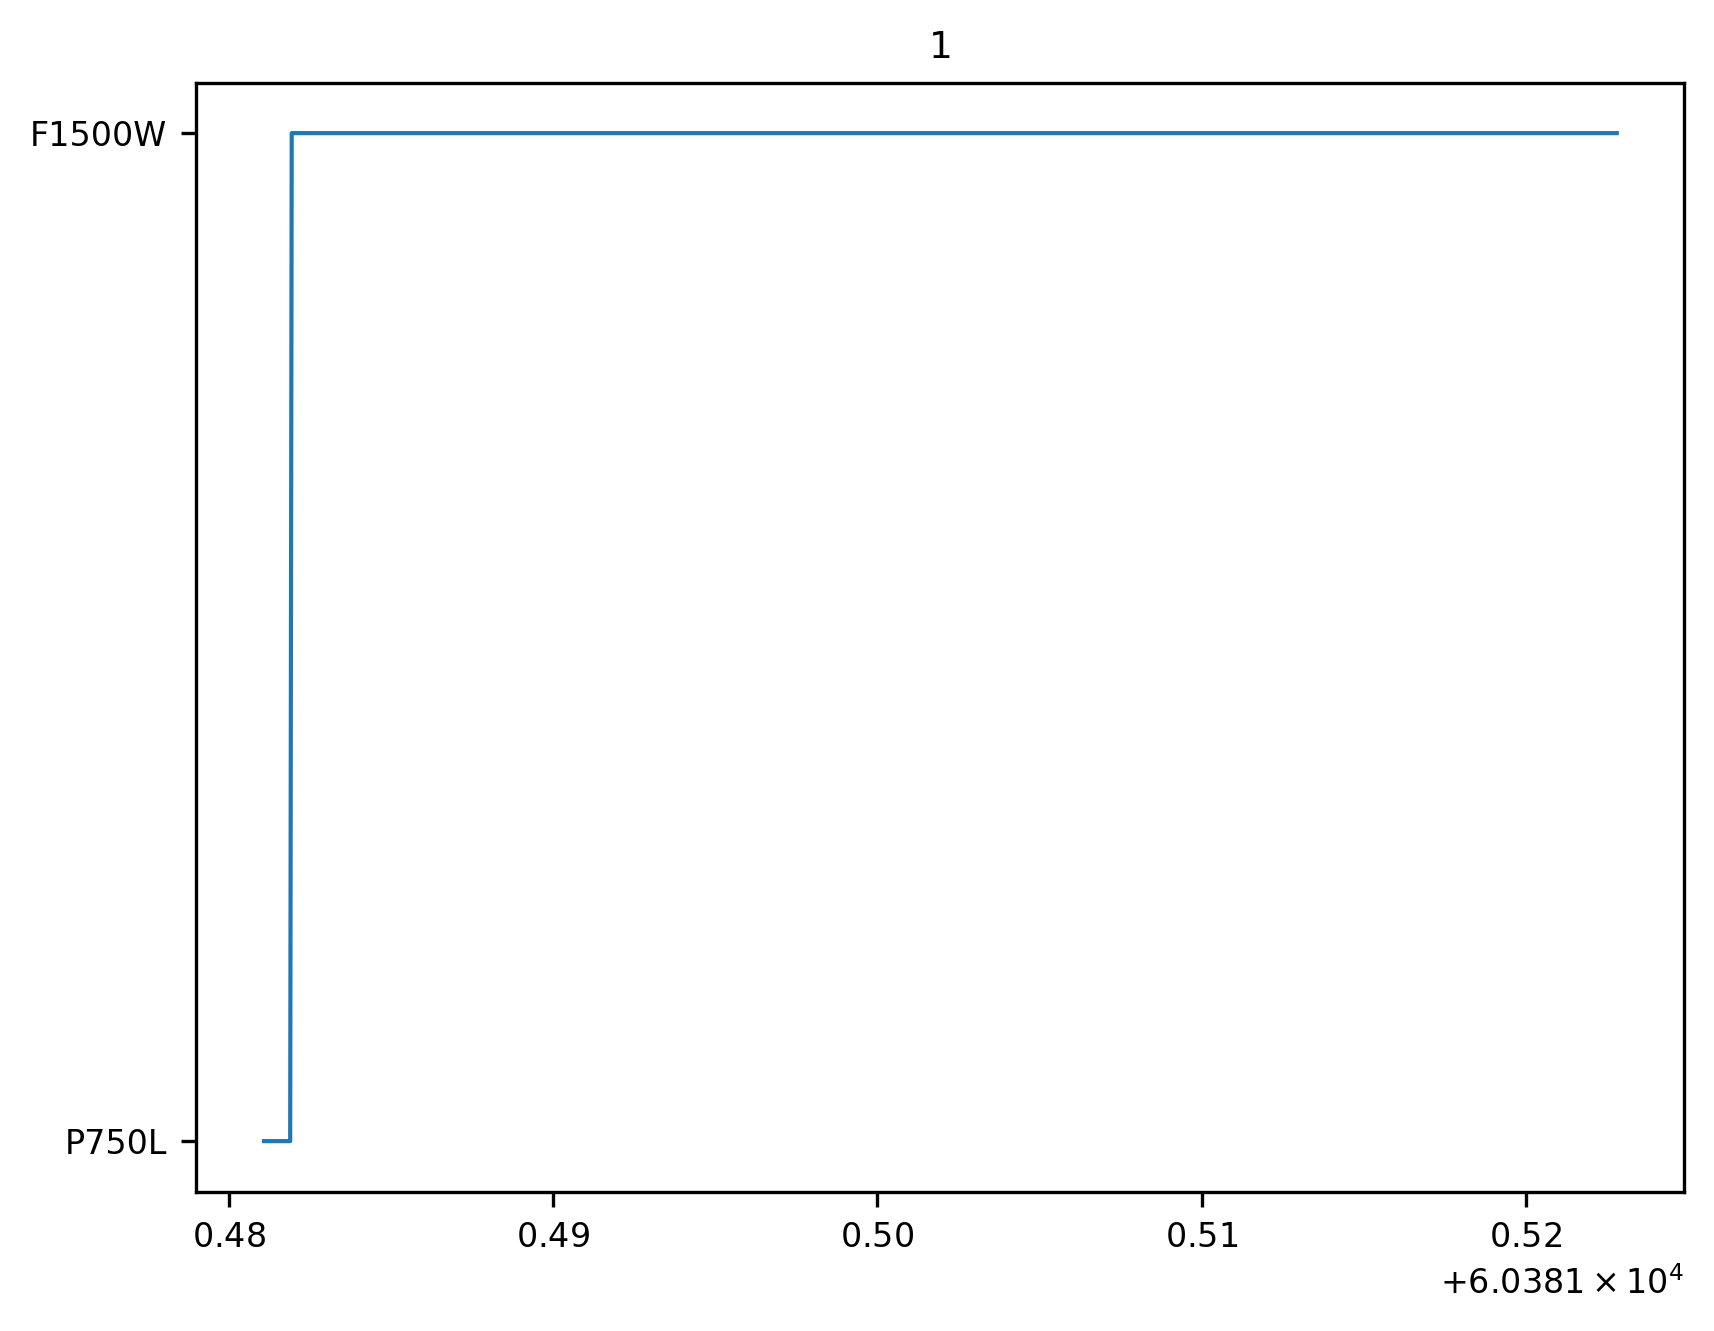

1.16 minutes
Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730002001_gs-fg_2024073191902-seg001/jw03730002001_gs-fg_2024073191902-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730002001_gs-fg_2024073191902-seg002/jw03730002001_gs-fg_2024073191902-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730002001_gs-fg_2024073191902-seg003/jw03730002001_gs-fg_2024073191902-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730002001_gs-fg_2024073191902-seg004/jw03730002001_gs-fg_2024073191902-seg004_cal.fits']
                    filenames                    
-------------------------------------------------
j

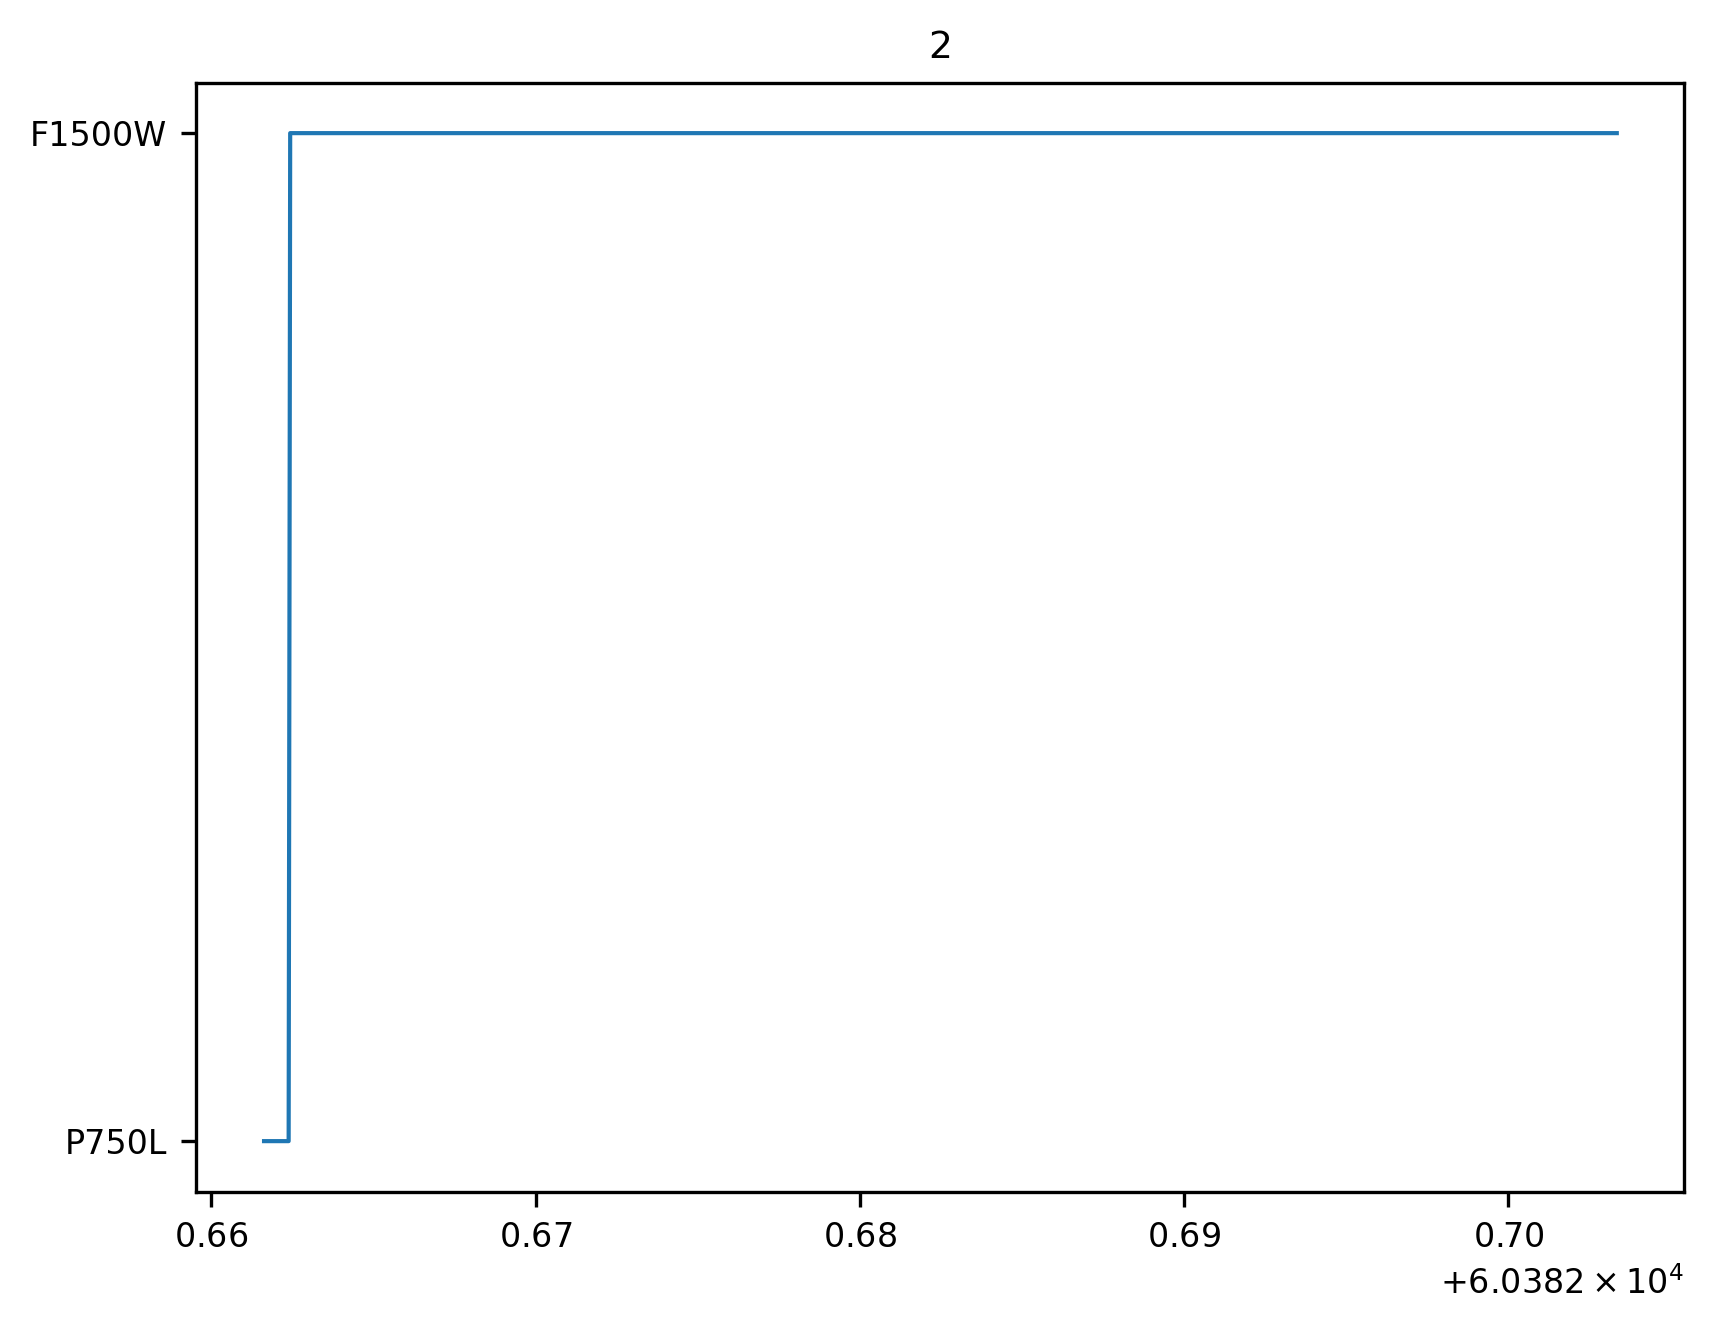

1.09 minutes
Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730004001_gs-fg_2024090134831-seg001/jw03730004001_gs-fg_2024090134831-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730004001_gs-fg_2024090134831-seg002/jw03730004001_gs-fg_2024090134831-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730004001_gs-fg_2024090134831-seg003/jw03730004001_gs-fg_2024090134831-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730004001_gs-fg_2024090134831-seg004/jw03730004001_gs-fg_2024090134831-seg004_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw0

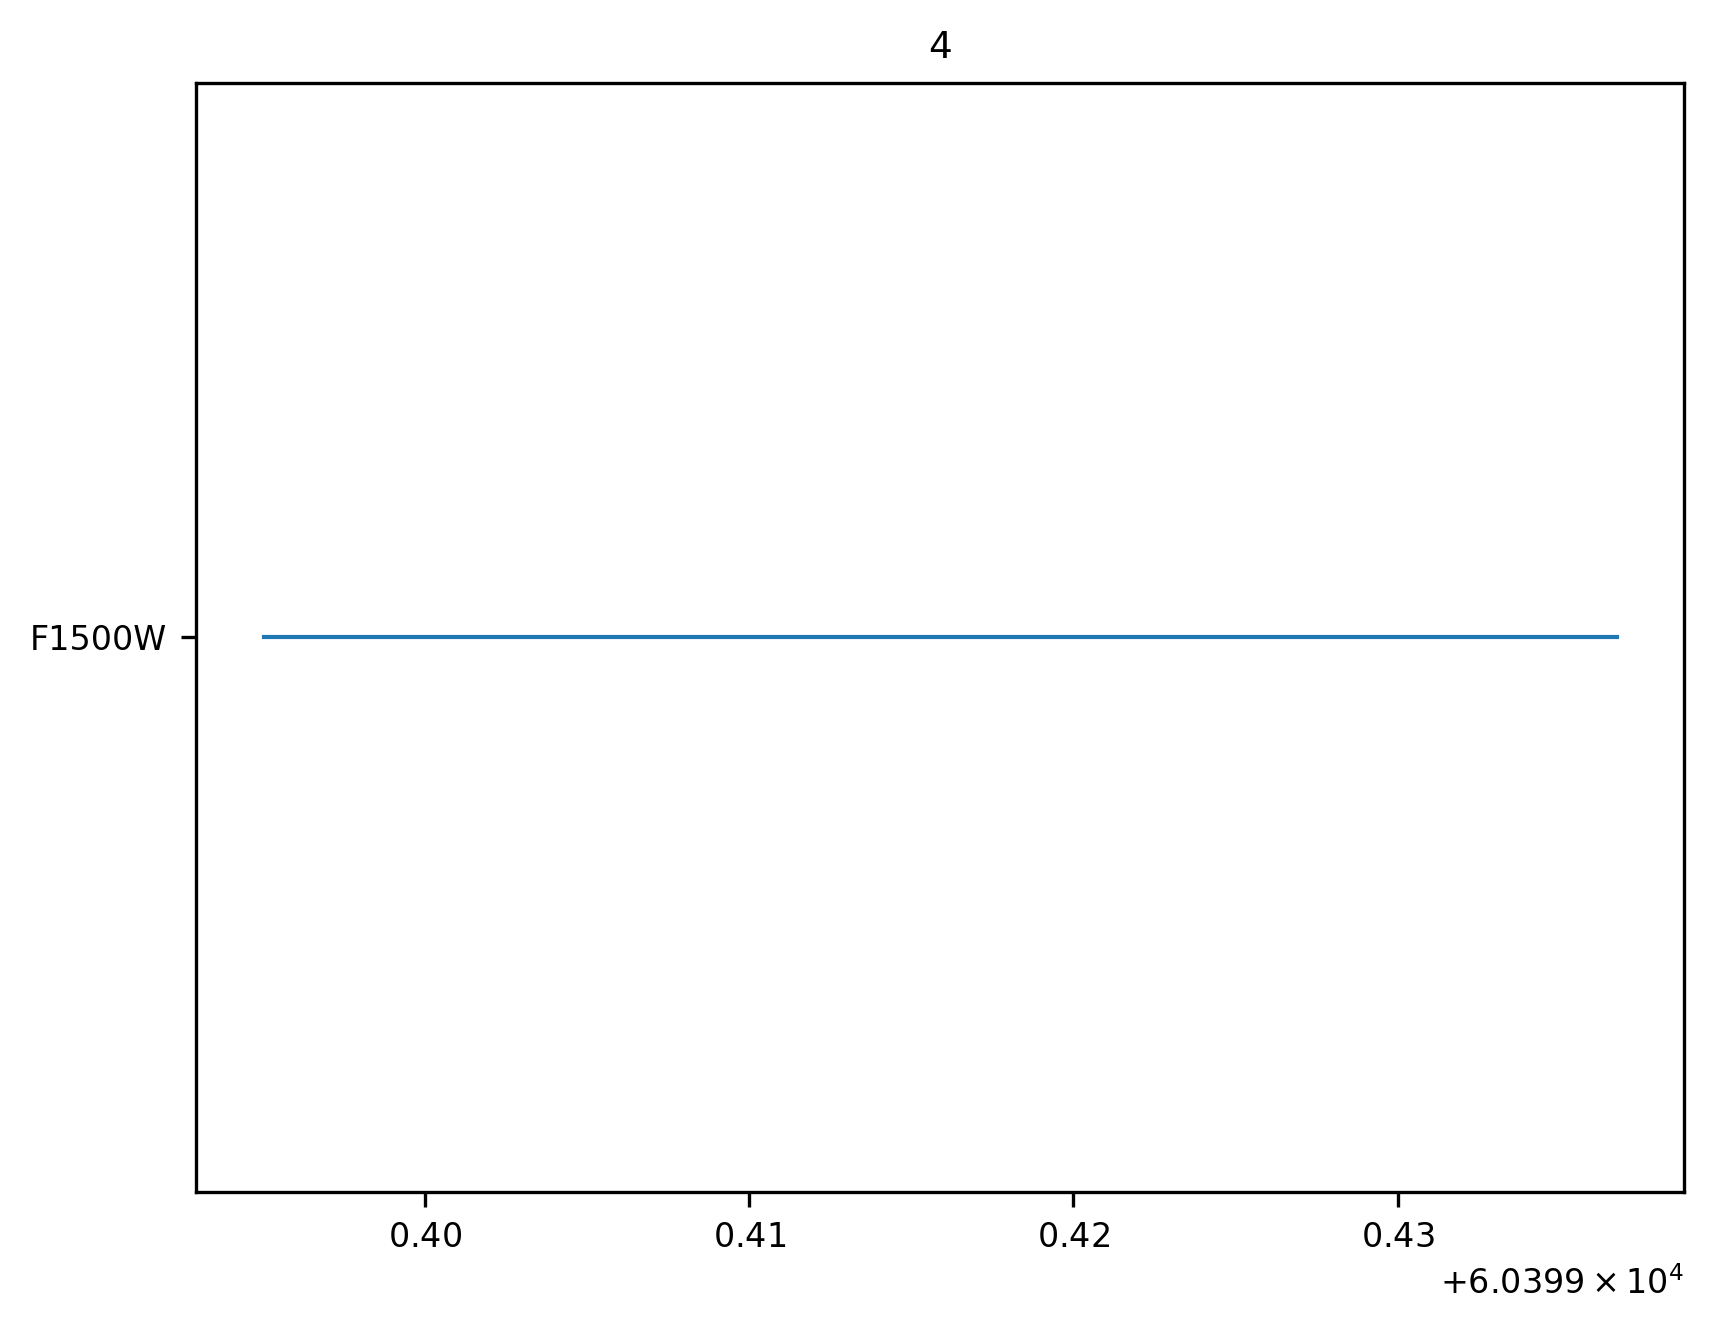

Visit 4 was not on P750L
Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730014001_gs-fg_2024126140747-seg001/jw03730014001_gs-fg_2024126140747-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730014001_gs-fg_2024126140747-seg002/jw03730014001_gs-fg_2024126140747-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730014001_gs-fg_2024126140747-seg003/jw03730014001_gs-fg_2024126140747-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730014001_gs-fg_2024126140747-seg004/jw03730014001_gs-fg_2024126140747-seg004_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownl

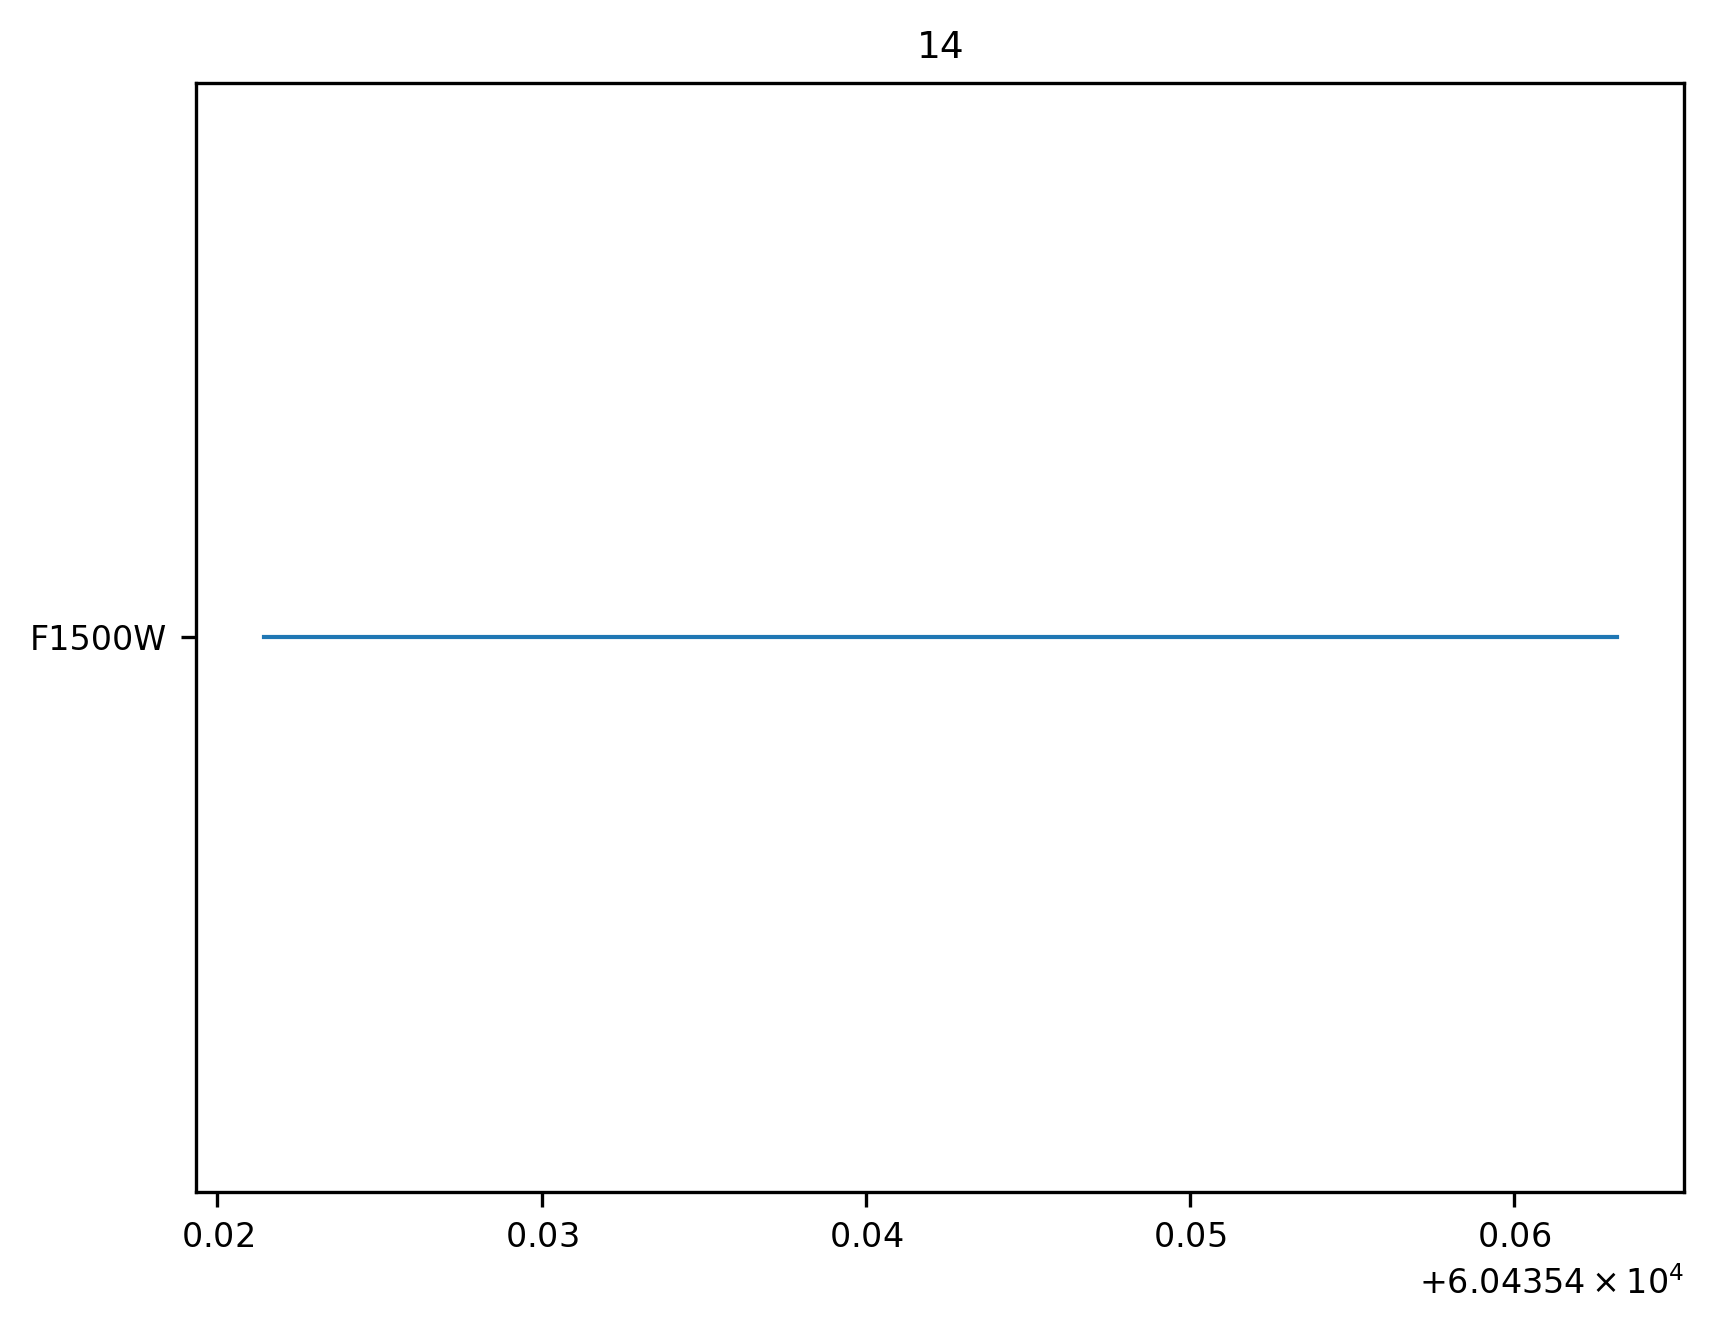

Visit 14 was not on P750L
Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730015001_gs-fg_2024125194130-seg001/jw03730015001_gs-fg_2024125194130-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730015001_gs-fg_2024125194130-seg002/jw03730015001_gs-fg_2024125194130-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730015001_gs-fg_2024125194130-seg003/jw03730015001_gs-fg_2024125194130-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730015001_gs-fg_2024125194130-seg004/jw03730015001_gs-fg_2024125194130-seg004_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDown

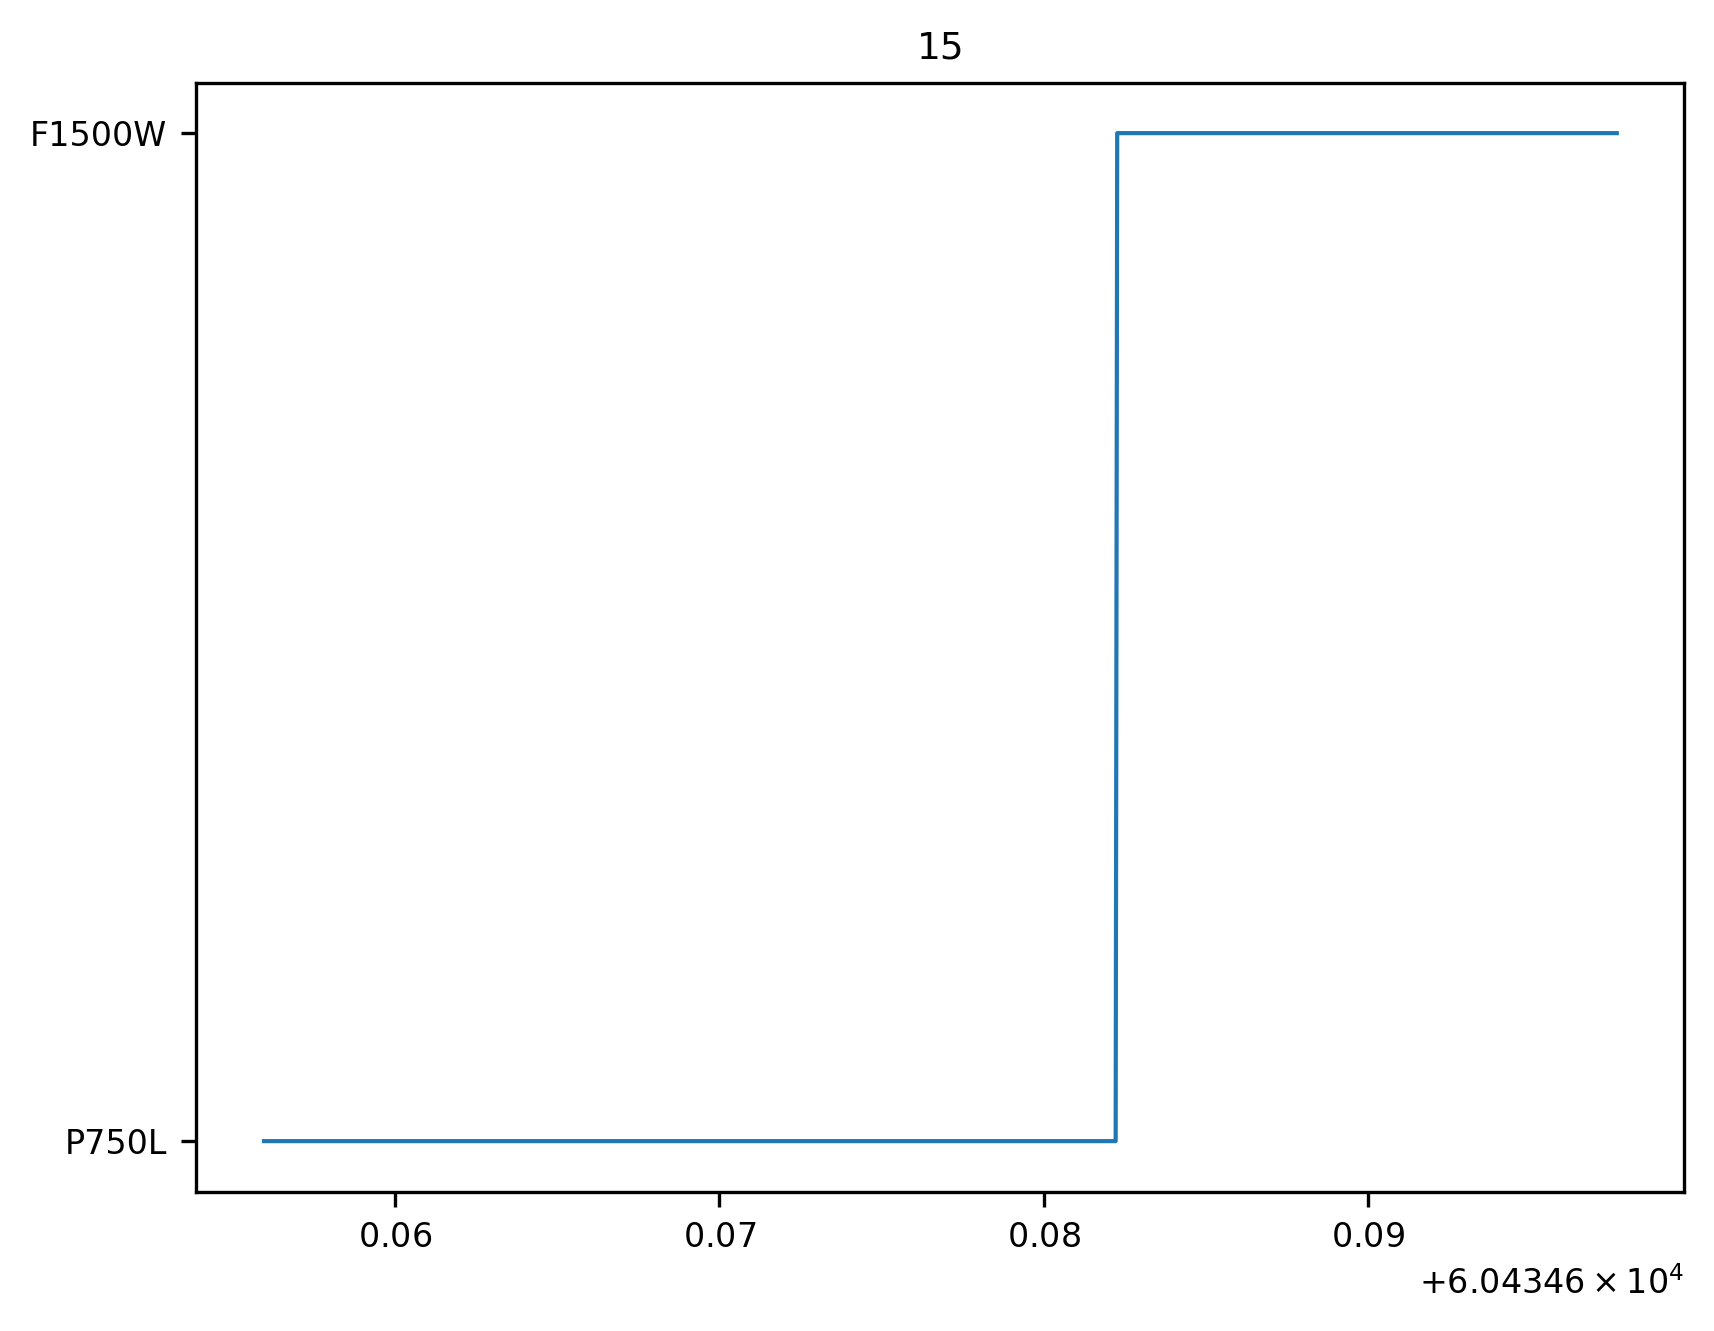

37.82 minutes
Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730019001_gs-fg_2024048093447-seg001/jw03730019001_gs-fg_2024048093447-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730019001_gs-fg_2024048093447-seg002/jw03730019001_gs-fg_2024048093447-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730019001_gs-fg_2024048093447-seg003/jw03730019001_gs-fg_2024048093447-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730019001_gs-fg_2024048093447-seg004/jw03730019001_gs-fg_2024048093447-seg004_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw

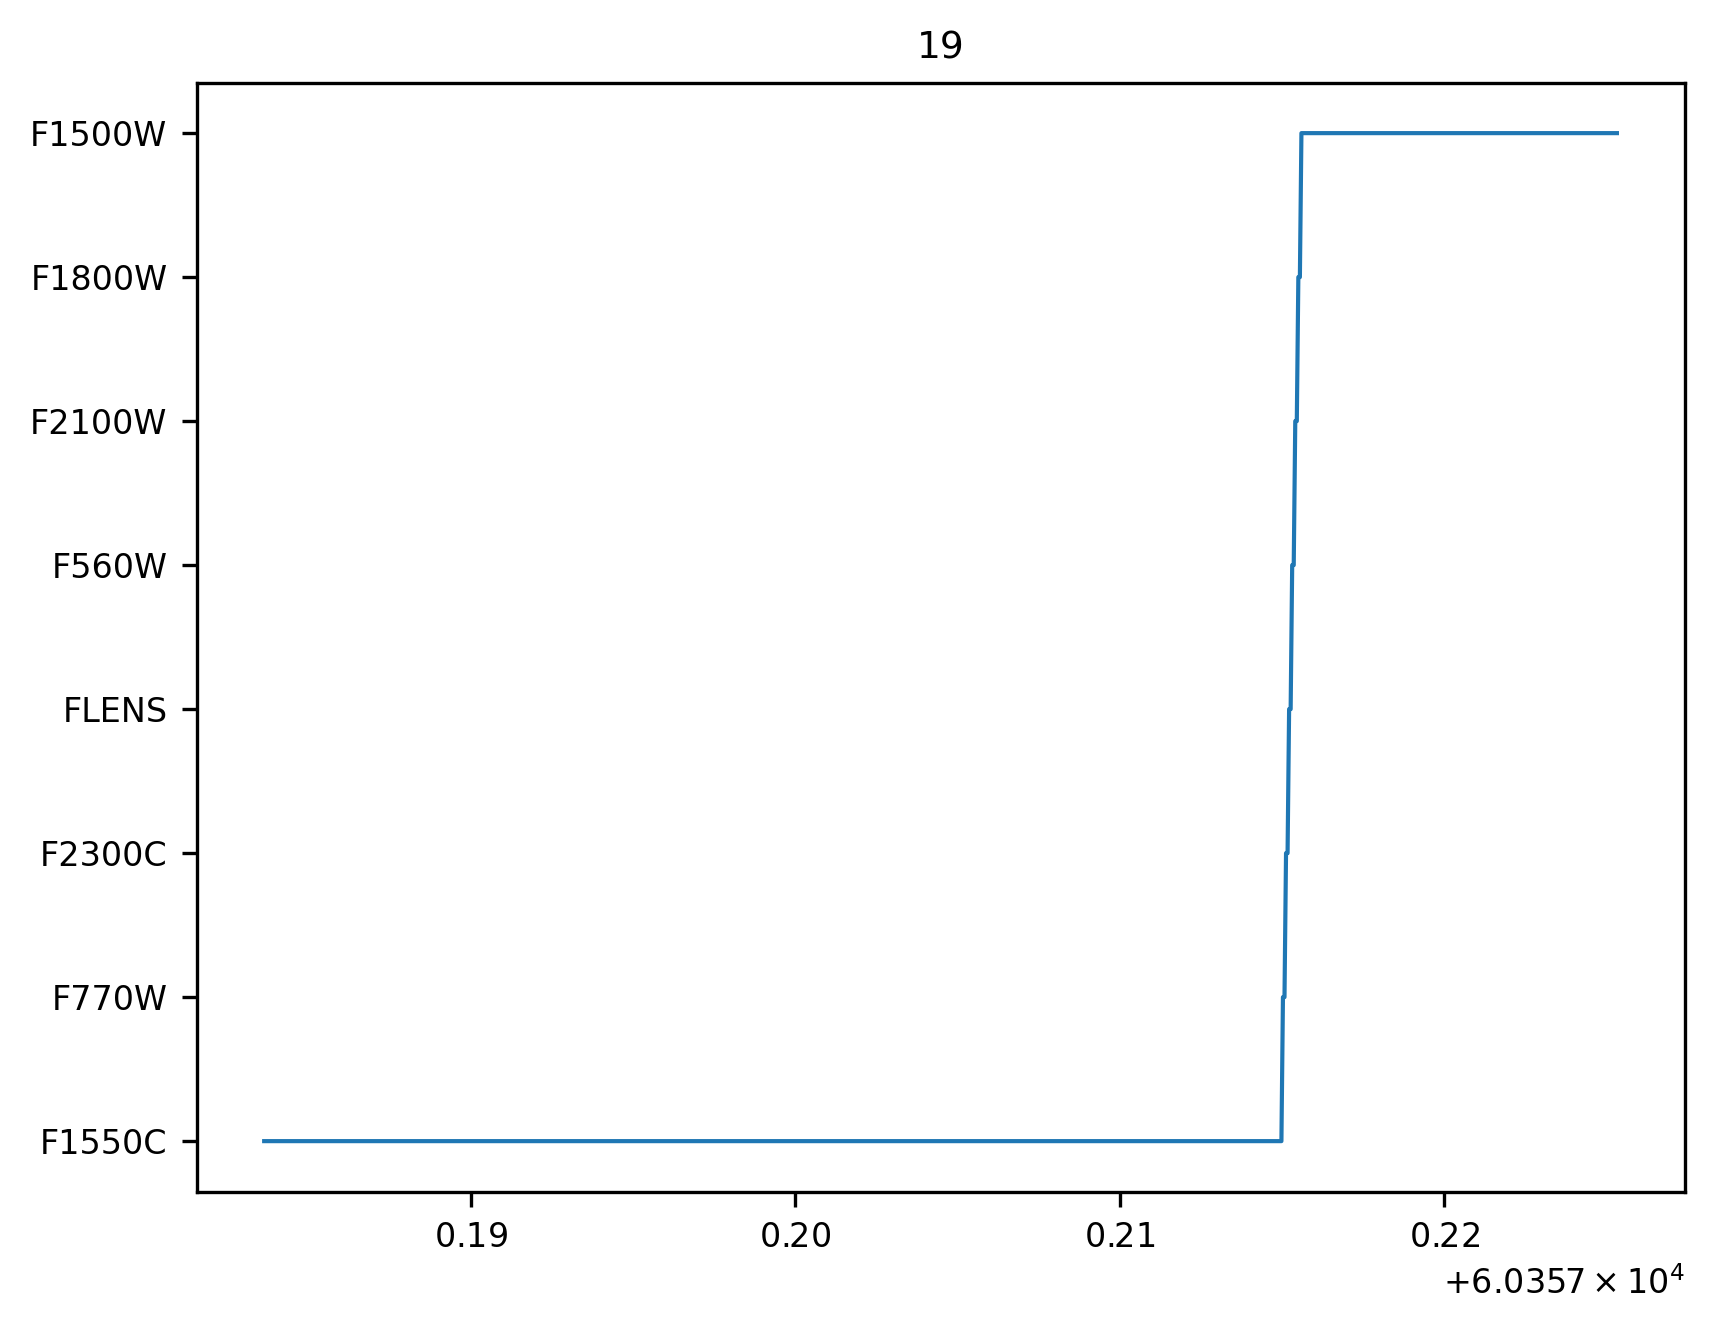

Visit 19 was not on P750L
Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730020001_gs-fg_2024041161624-seg001/jw03730020001_gs-fg_2024041161624-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730020001_gs-fg_2024041161624-seg002/jw03730020001_gs-fg_2024041161624-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730020001_gs-fg_2024041161624-seg003/jw03730020001_gs-fg_2024041161624-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730020001_gs-fg_2024041161624-seg004/jw03730020001_gs-fg_2024041161624-seg004_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDown

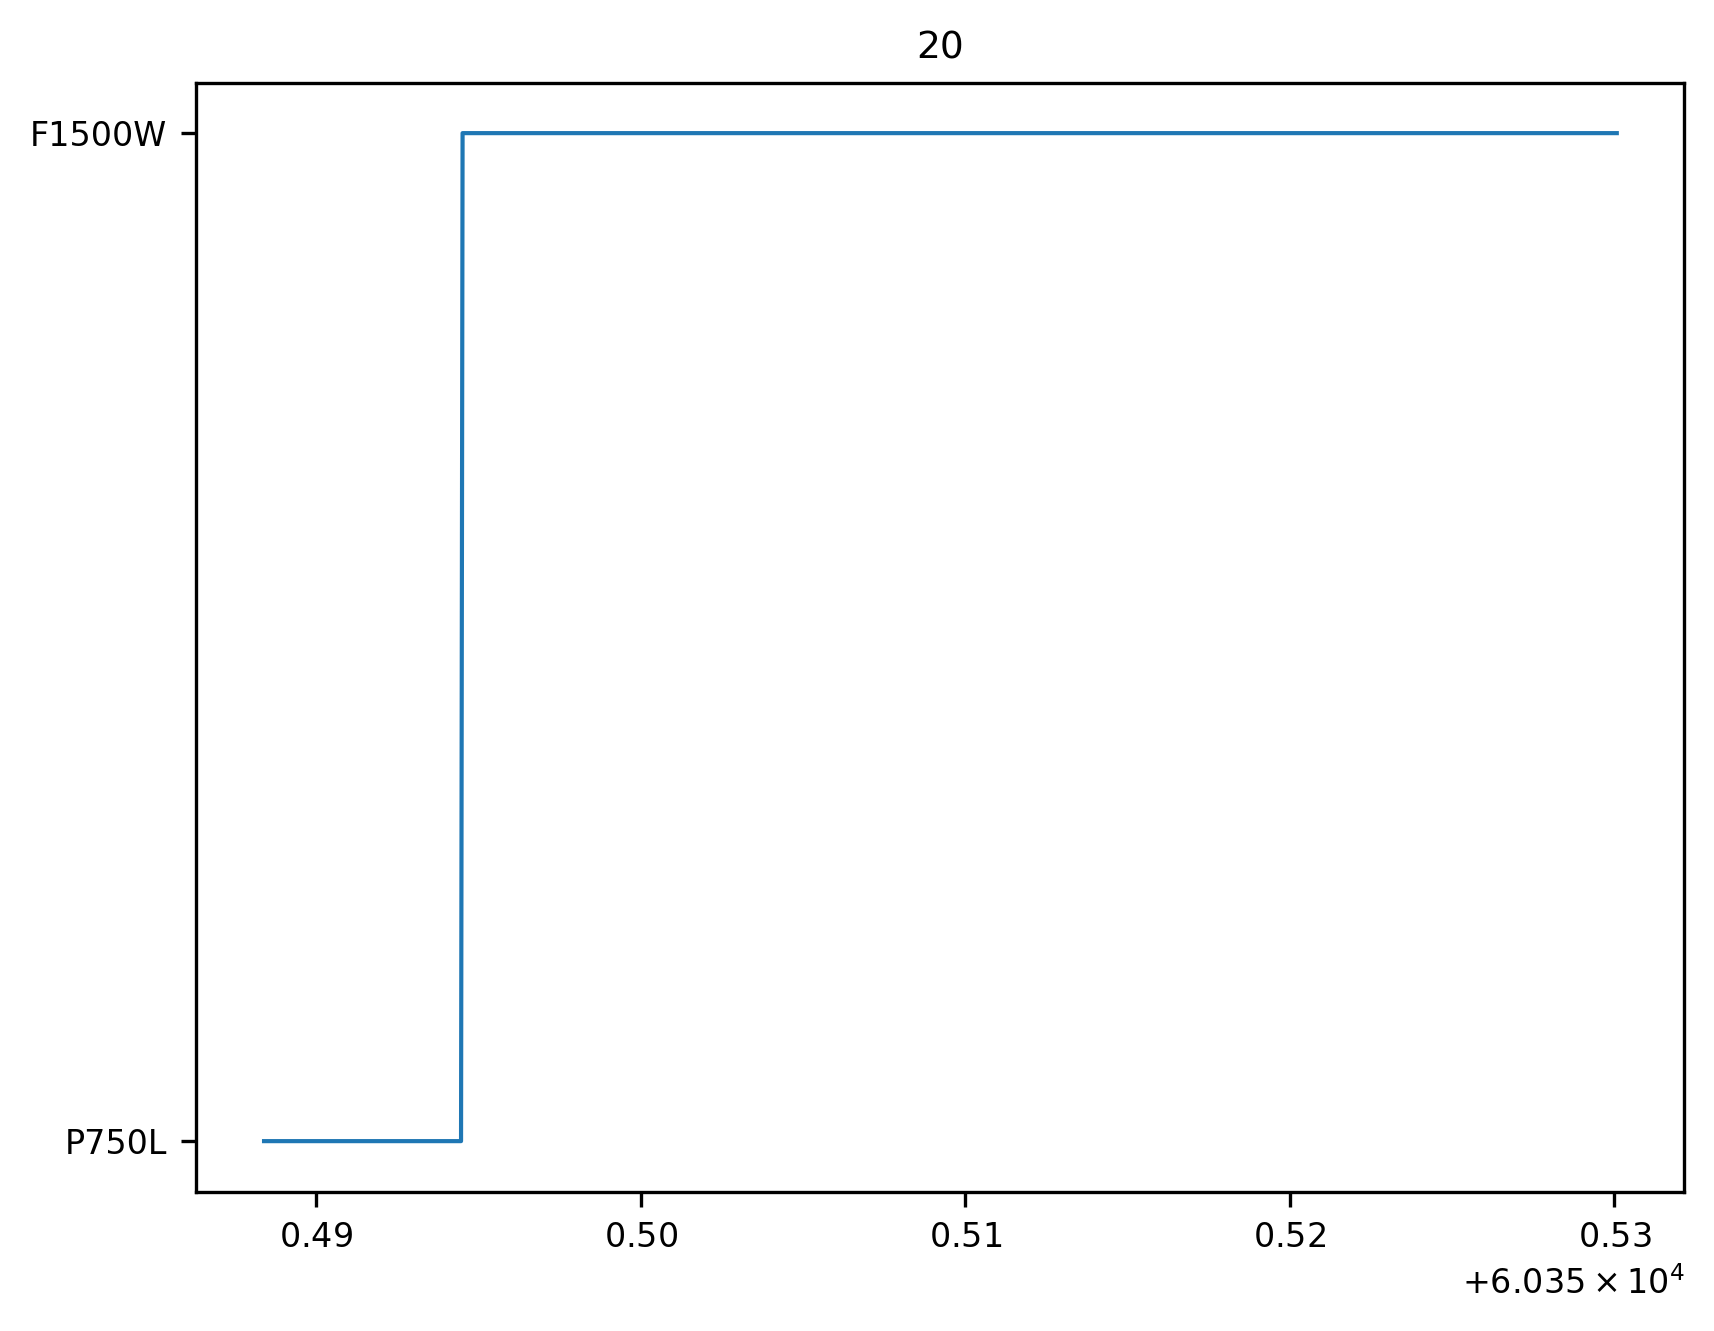

8.74 minutes
Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730021001_gs-fg_2024038073733-seg001/jw03730021001_gs-fg_2024038073733-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730021001_gs-fg_2024038073733-seg002/jw03730021001_gs-fg_2024038073733-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730021001_gs-fg_2024038073733-seg003/jw03730021001_gs-fg_2024038073733-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730021001_gs-fg_2024038073733-seg004/jw03730021001_gs-fg_2024038073733-seg004_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw0

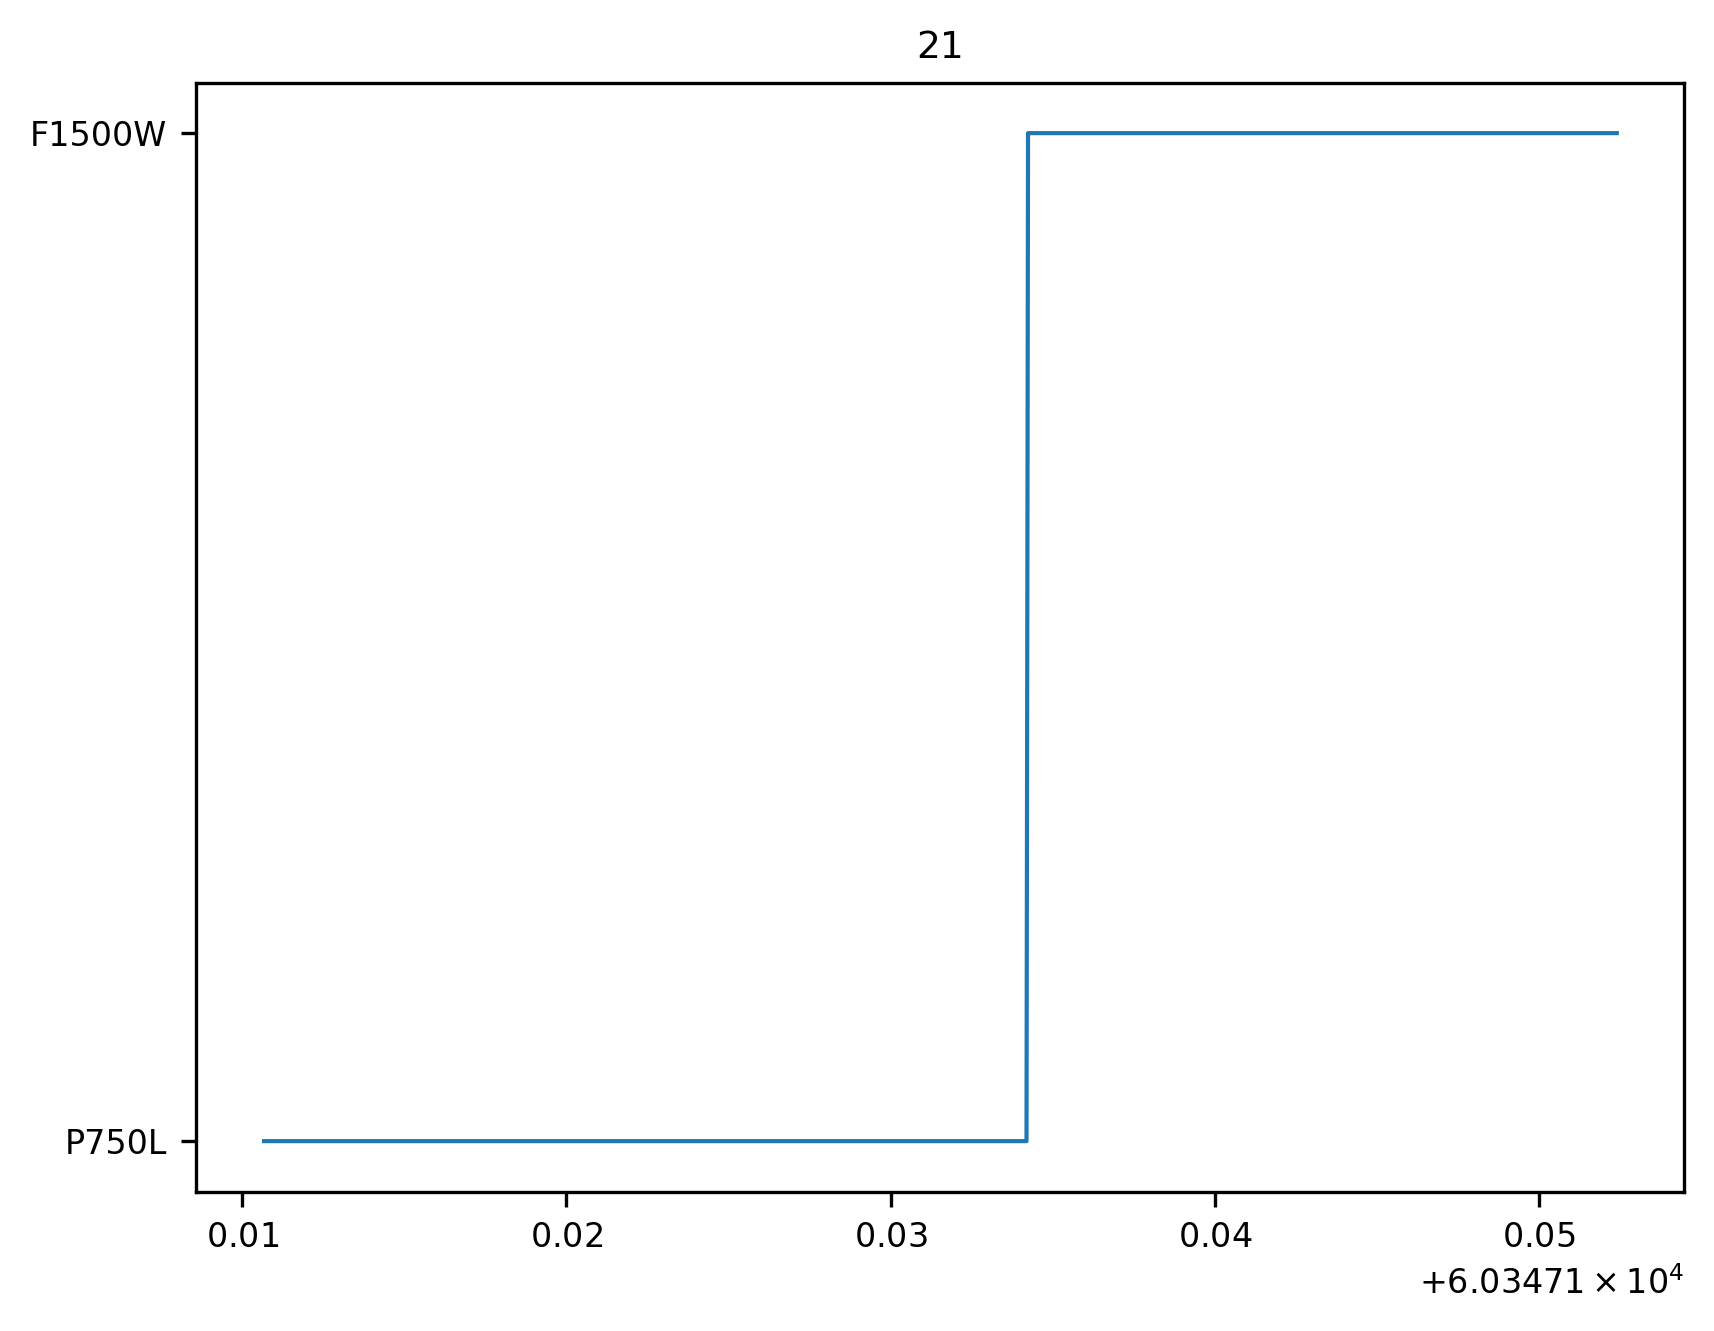

33.86 minutes
Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730022001_gs-fg_2024031142002-seg001/jw03730022001_gs-fg_2024031142002-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730022001_gs-fg_2024031142002-seg002/jw03730022001_gs-fg_2024031142002-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730022001_gs-fg_2024031142002-seg003/jw03730022001_gs-fg_2024031142002-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730022001_gs-fg_2024031142002-seg004/jw03730022001_gs-fg_2024031142002-seg004_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw

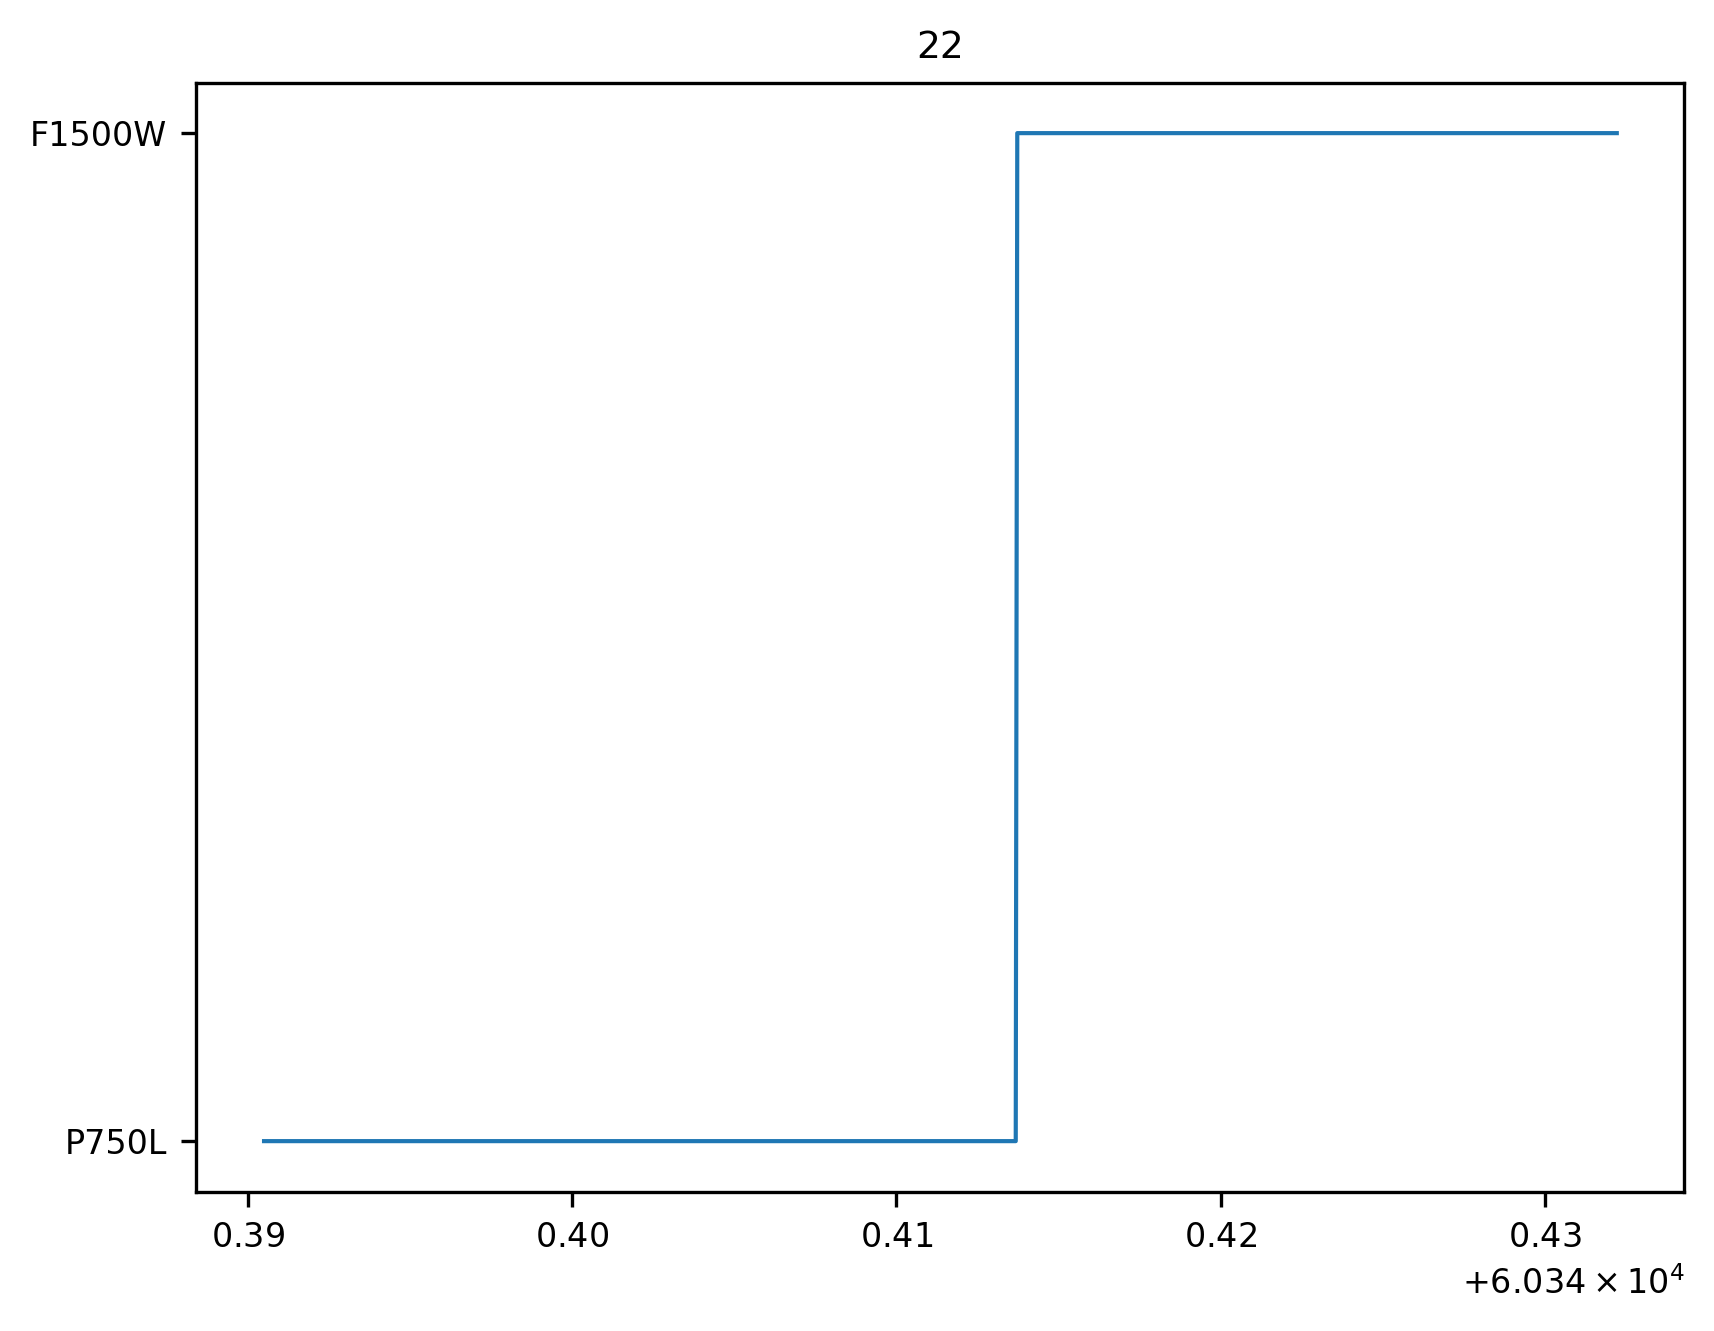

33.38 minutes
Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730029001_gs-fg_2024294054438-seg001/jw03730029001_gs-fg_2024294054438-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730029001_gs-fg_2024294054438-seg002/jw03730029001_gs-fg_2024294054438-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730029001_gs-fg_2024294054438-seg003/jw03730029001_gs-fg_2024294054438-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730029001_gs-fg_2024294054438-seg004/jw03730029001_gs-fg_2024294054438-seg004_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw

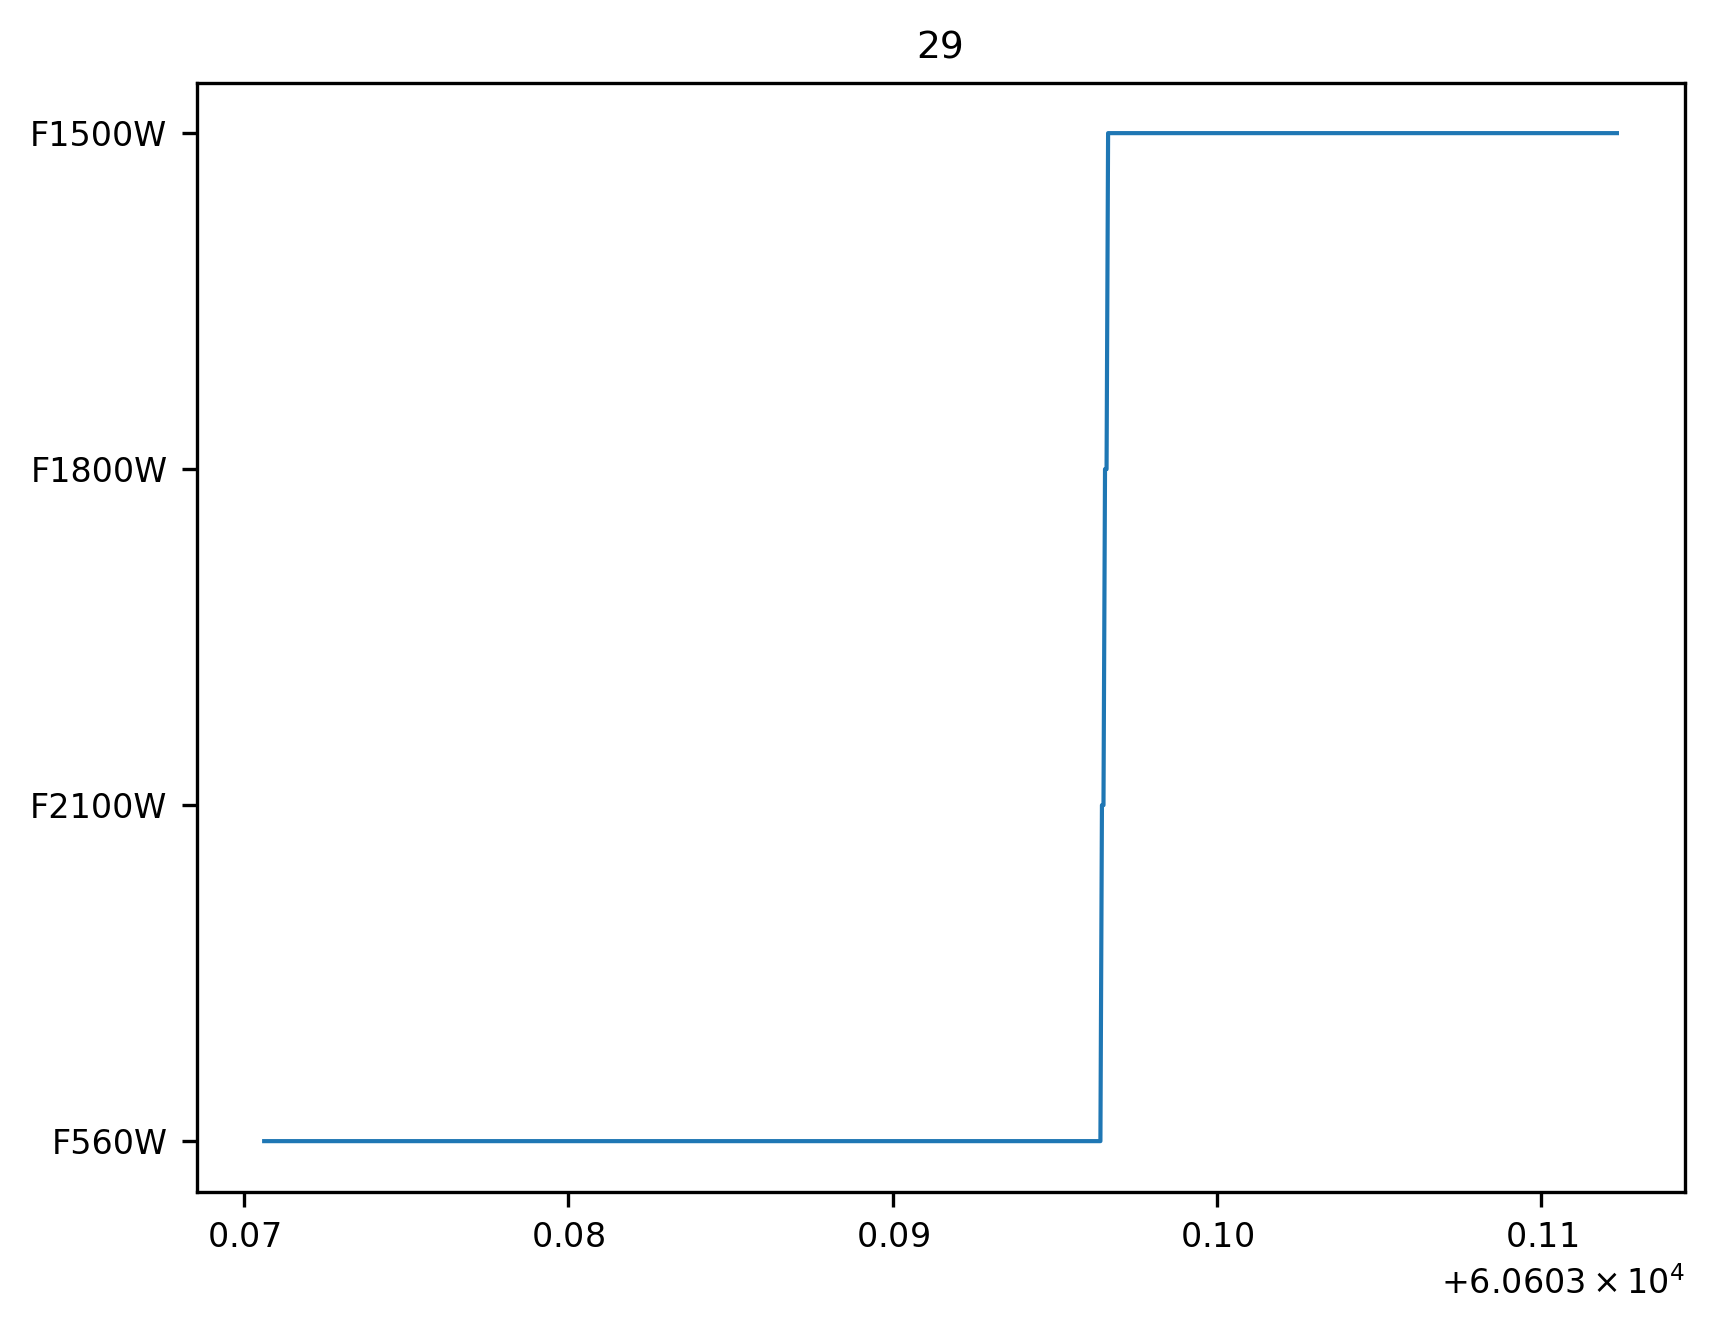

Visit 29 was not on P750L


In [7]:
# 4, 29, 14 wasnt on P750L
# 1, 2, 4, and 29 are the same -> GJ3473b
# 14, 15 -> LTT3780b
# 19, 20, 21, 22 -> L231-32b
hot_rocks = []
for i in hot_rocks_ids:
	hot_rocks.append(get_p750L(3730, i))
hot_rocks = np.array(hot_rocks)

1
-0.18+/-0.04
2
-0.18+/-0.04
15
-0.050+/-0.034
20
-0.145+/-0.034
21
-0.085+/-0.035
22
0.08+/-0.04


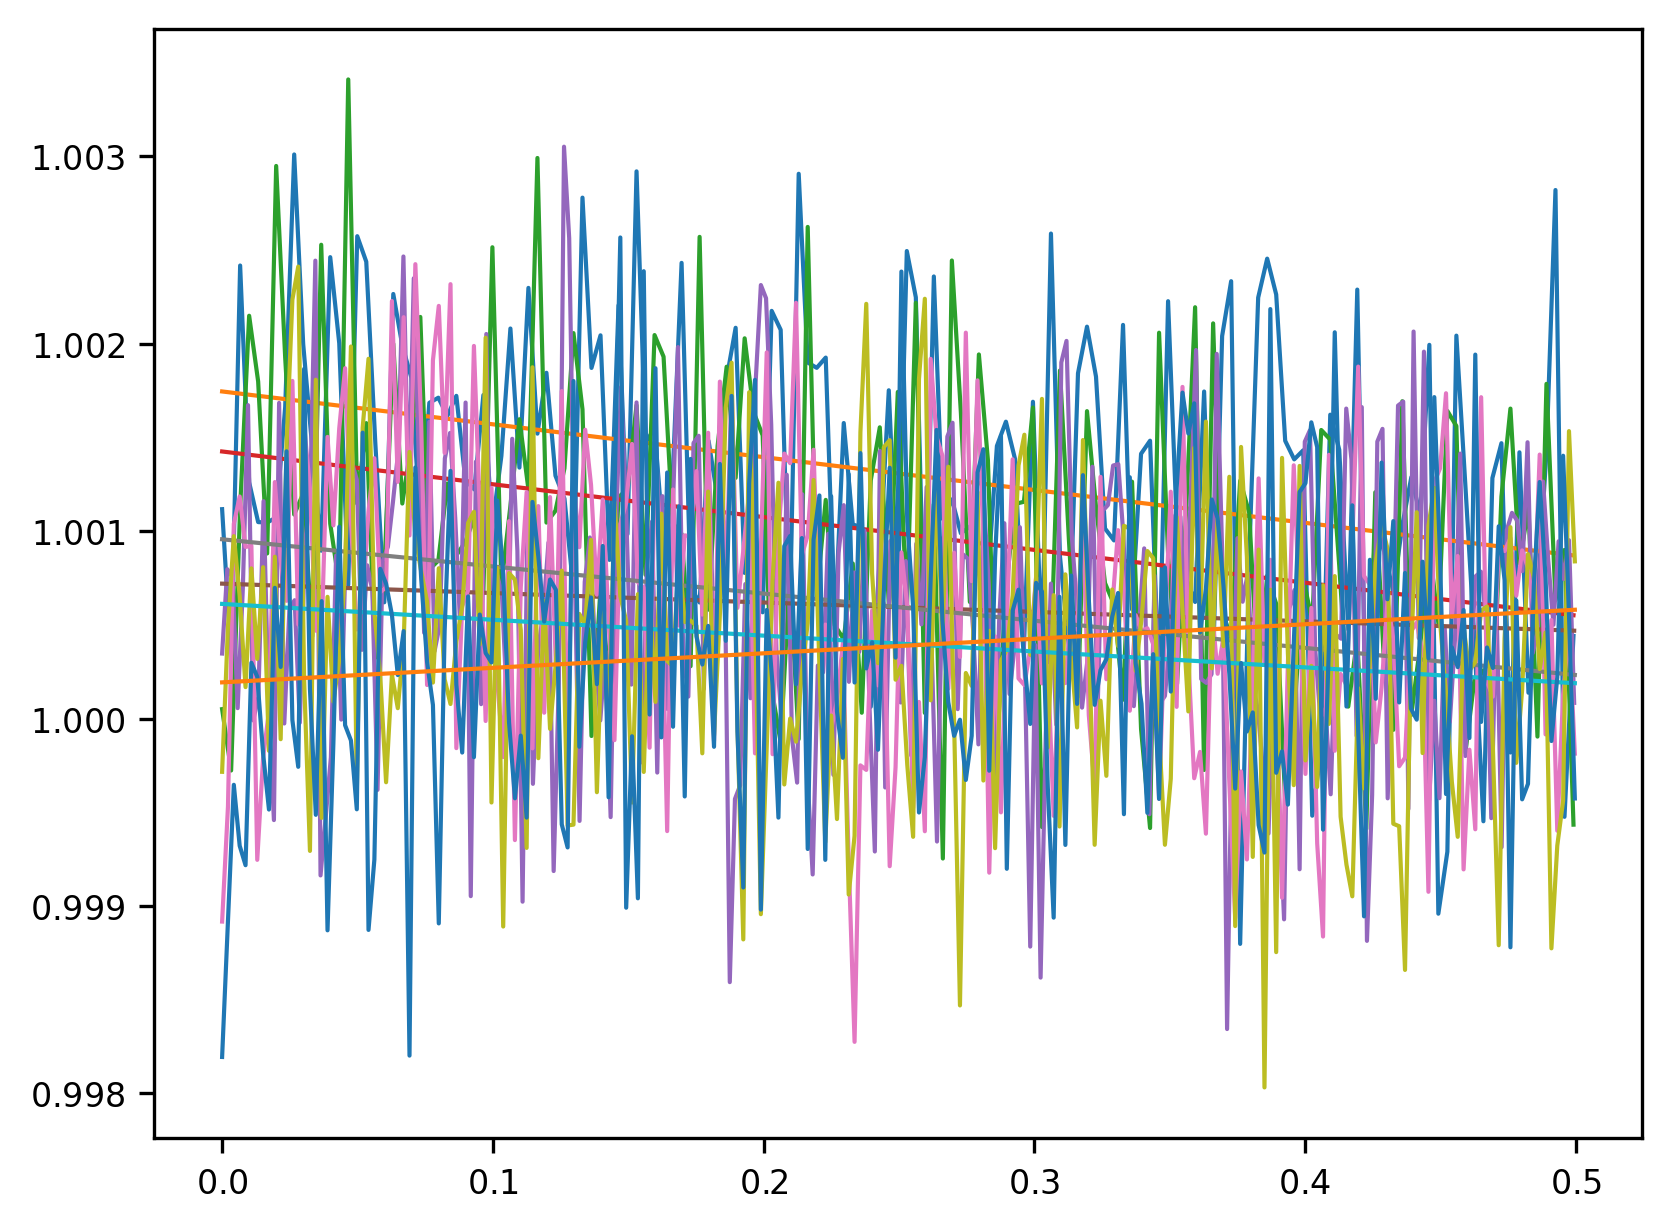

In [8]:
hot_rocks_slopes = []
for i in range(len(hot_rocks_ids)):
	if hot_rocks[i] == 0:
		hot_rocks_slopes.append(0)
	else:	
		obs_num = hot_rocks_ids[i]
		print(obs_num)
		hot_rocks_slopes.append(fit_slope(PhotometryData.load(glob(f"./Previous settling ramps/jw03730*{obs_num}001_5_12_20*.h5")[0])))
hot_rocks_slopes = np.array(hot_rocks_slopes)

Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235001001_gs-fg_2025189132123-seg001/jw09235001001_gs-fg_2025189132123-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235001001_gs-fg_2025189132123-seg002/jw09235001001_gs-fg_2025189132123-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235001001_gs-fg_2025189132123-seg003/jw09235001001_gs-fg_2025189132123-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235001001_gs-fg_2025189132123-seg004/jw09235001001_gs-fg_2025189132123-seg004_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235001001_gs

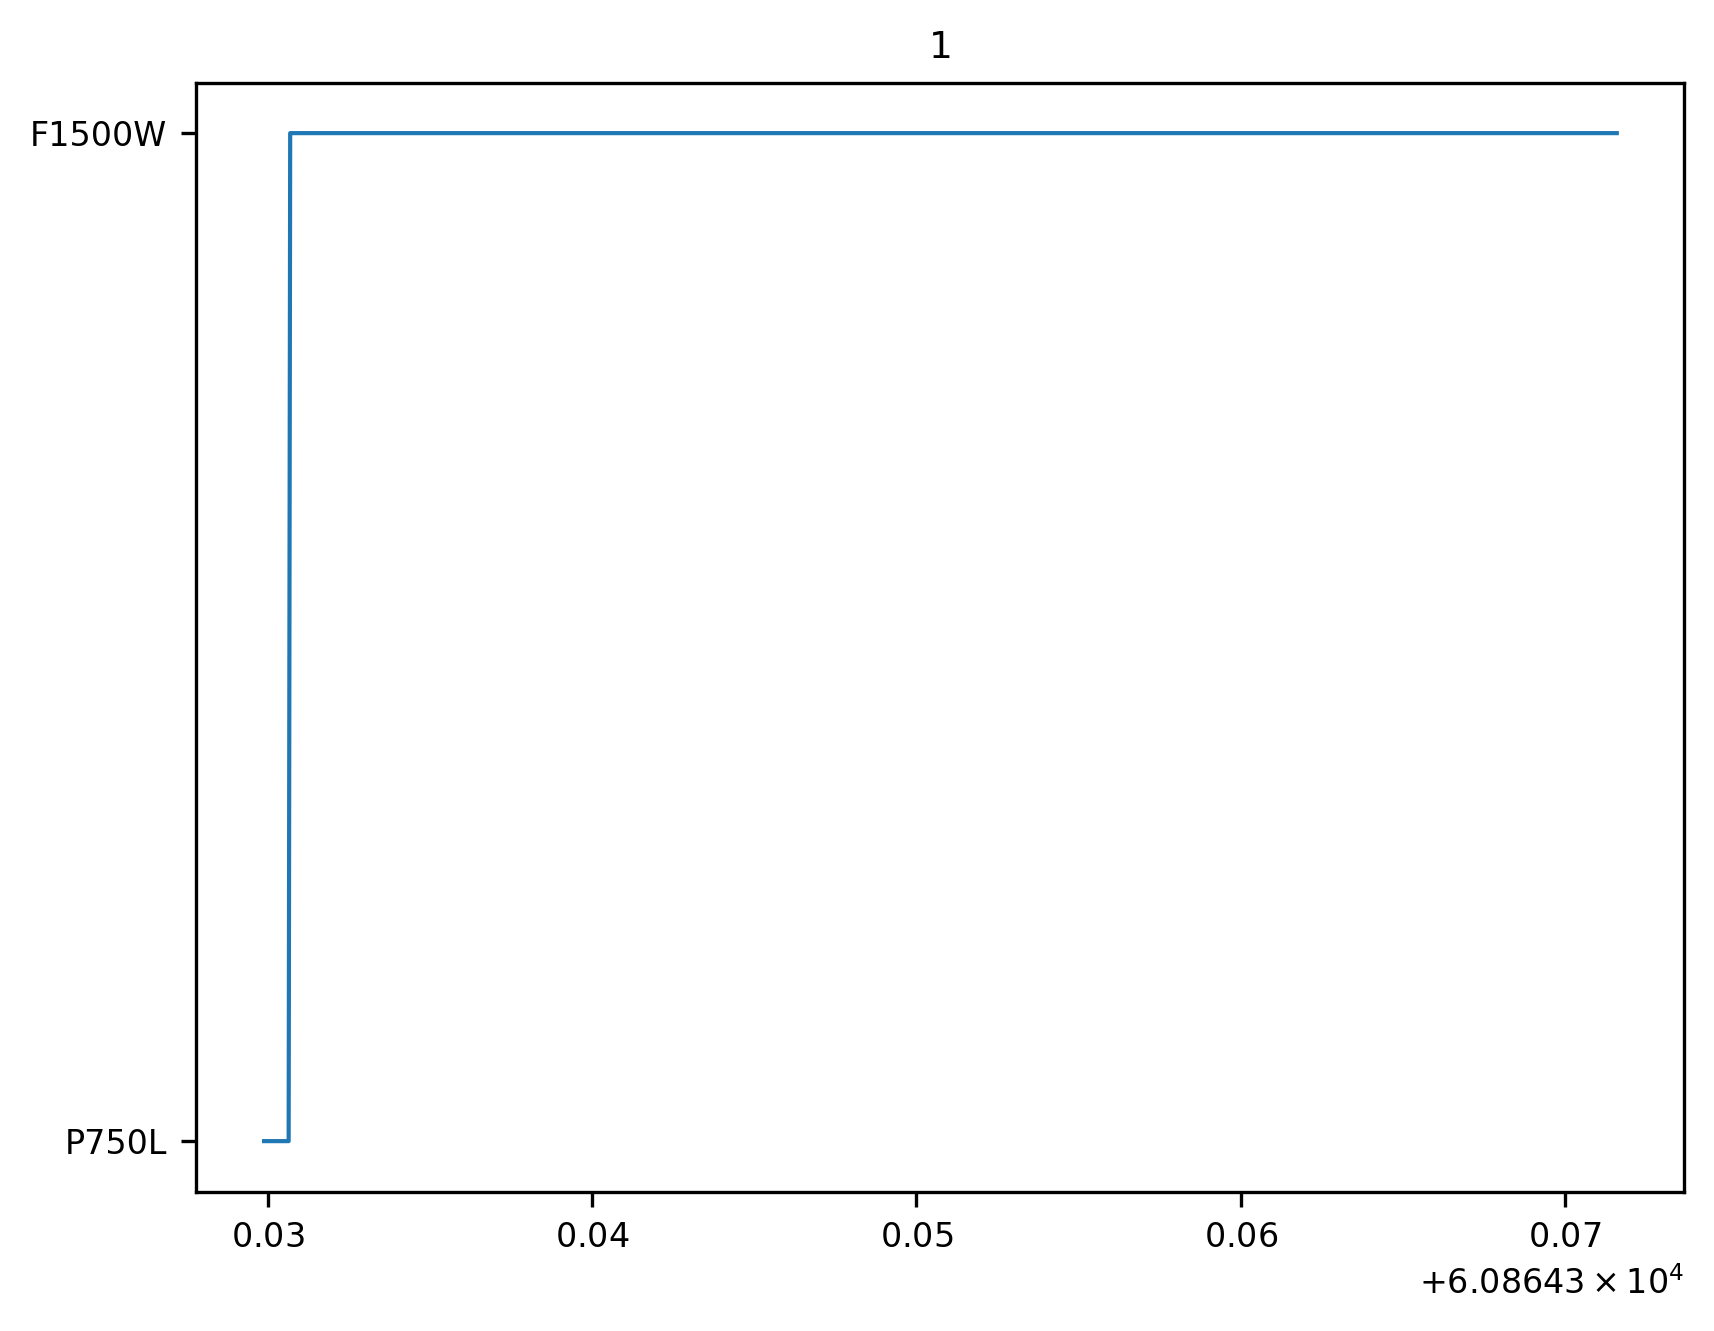

1.09 minutes
Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235002001_gs-fg_2025213014921-seg001/jw09235002001_gs-fg_2025213014921-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235002001_gs-fg_2025213014921-seg002/jw09235002001_gs-fg_2025213014921-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235002001_gs-fg_2025213014921-seg003/jw09235002001_gs-fg_2025213014921-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235002001_gs-fg_2025213014921-seg004/jw09235002001_gs-fg_2025213014921-seg004_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw0

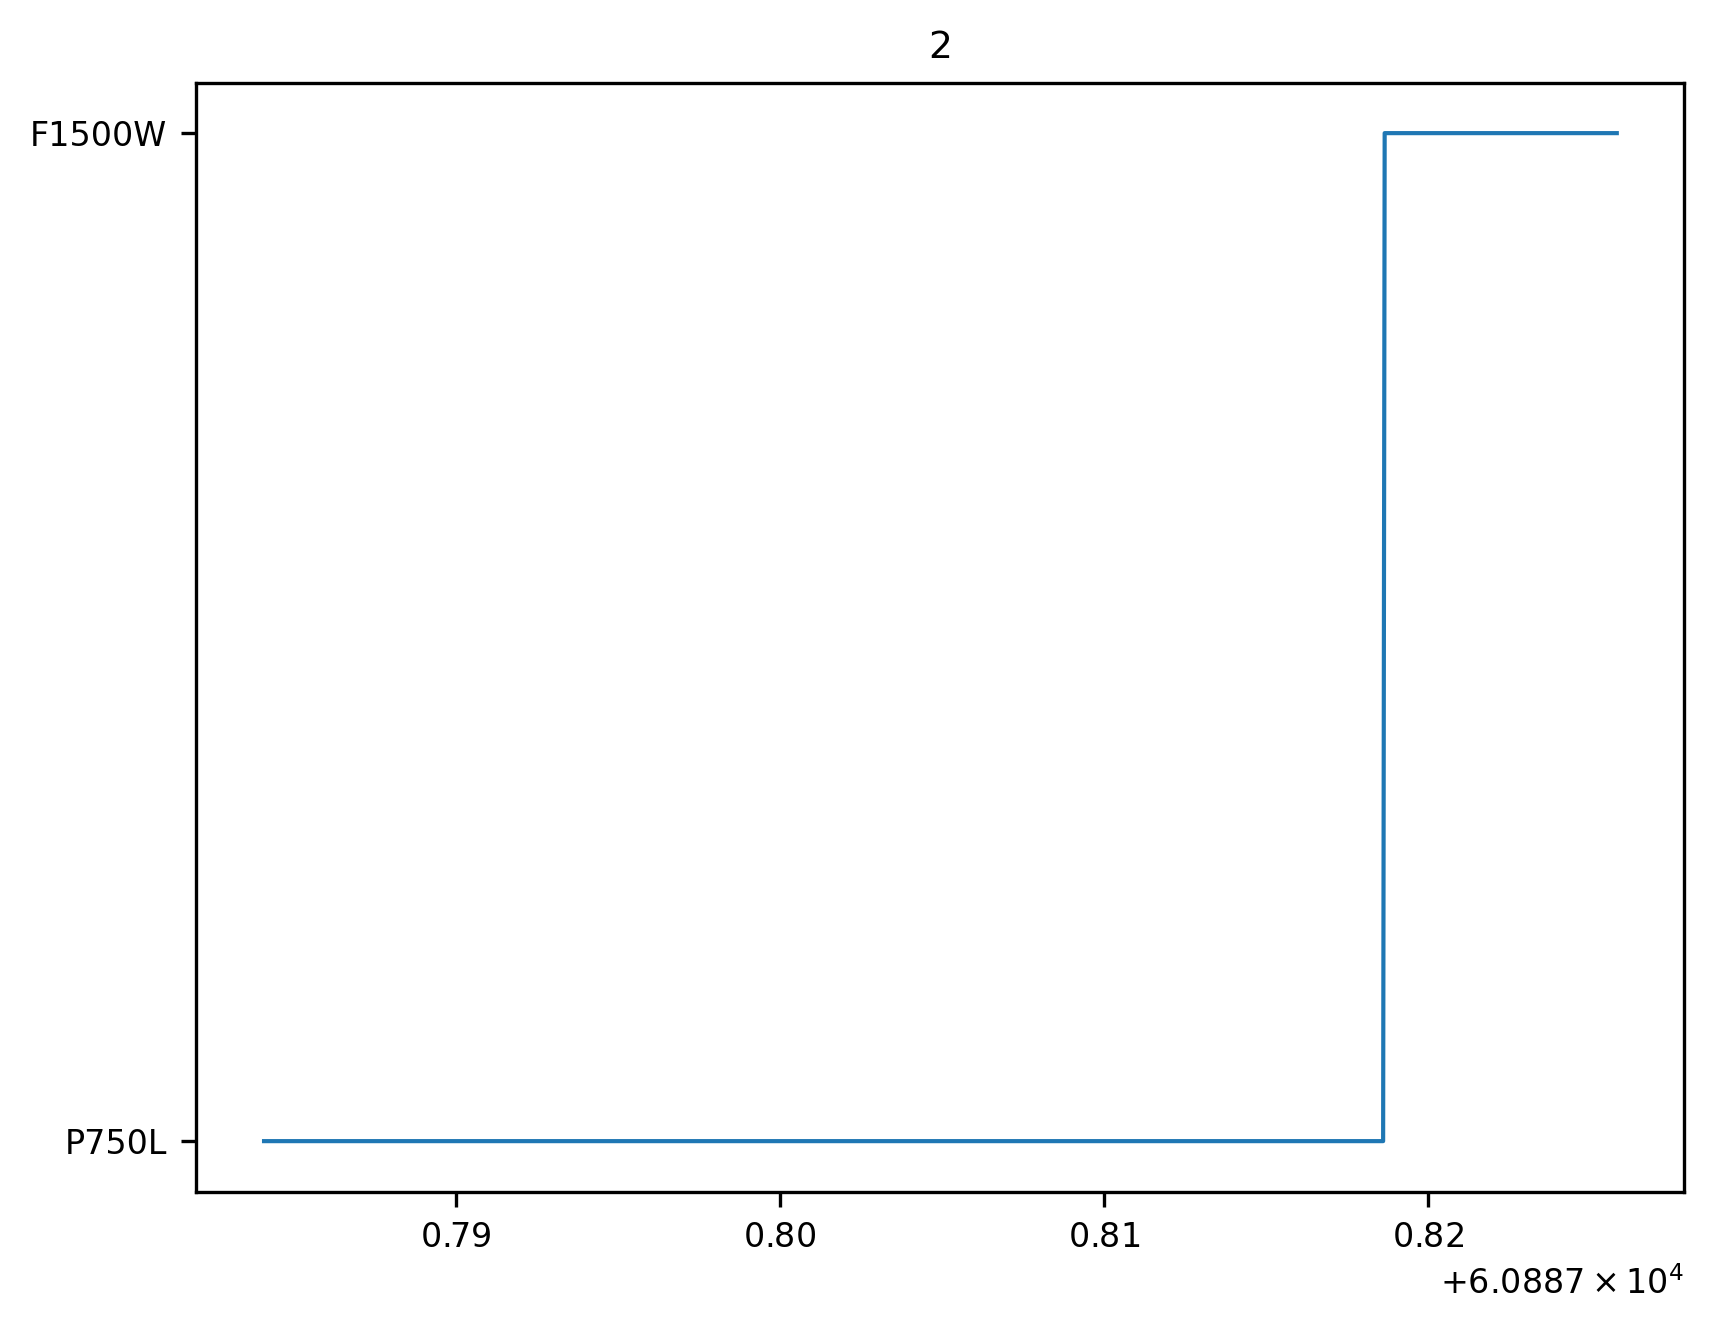

49.70 minutes
Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235003001_gs-fg_2026031050954-seg001/jw09235003001_gs-fg_2026031050954-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235003001_gs-fg_2026031050954-seg002/jw09235003001_gs-fg_2026031050954-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235003001_gs-fg_2026031050954-seg003/jw09235003001_gs-fg_2026031050954-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235003001_gs-fg_2026031050954-seg004/jw09235003001_gs-fg_2026031050954-seg004_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw

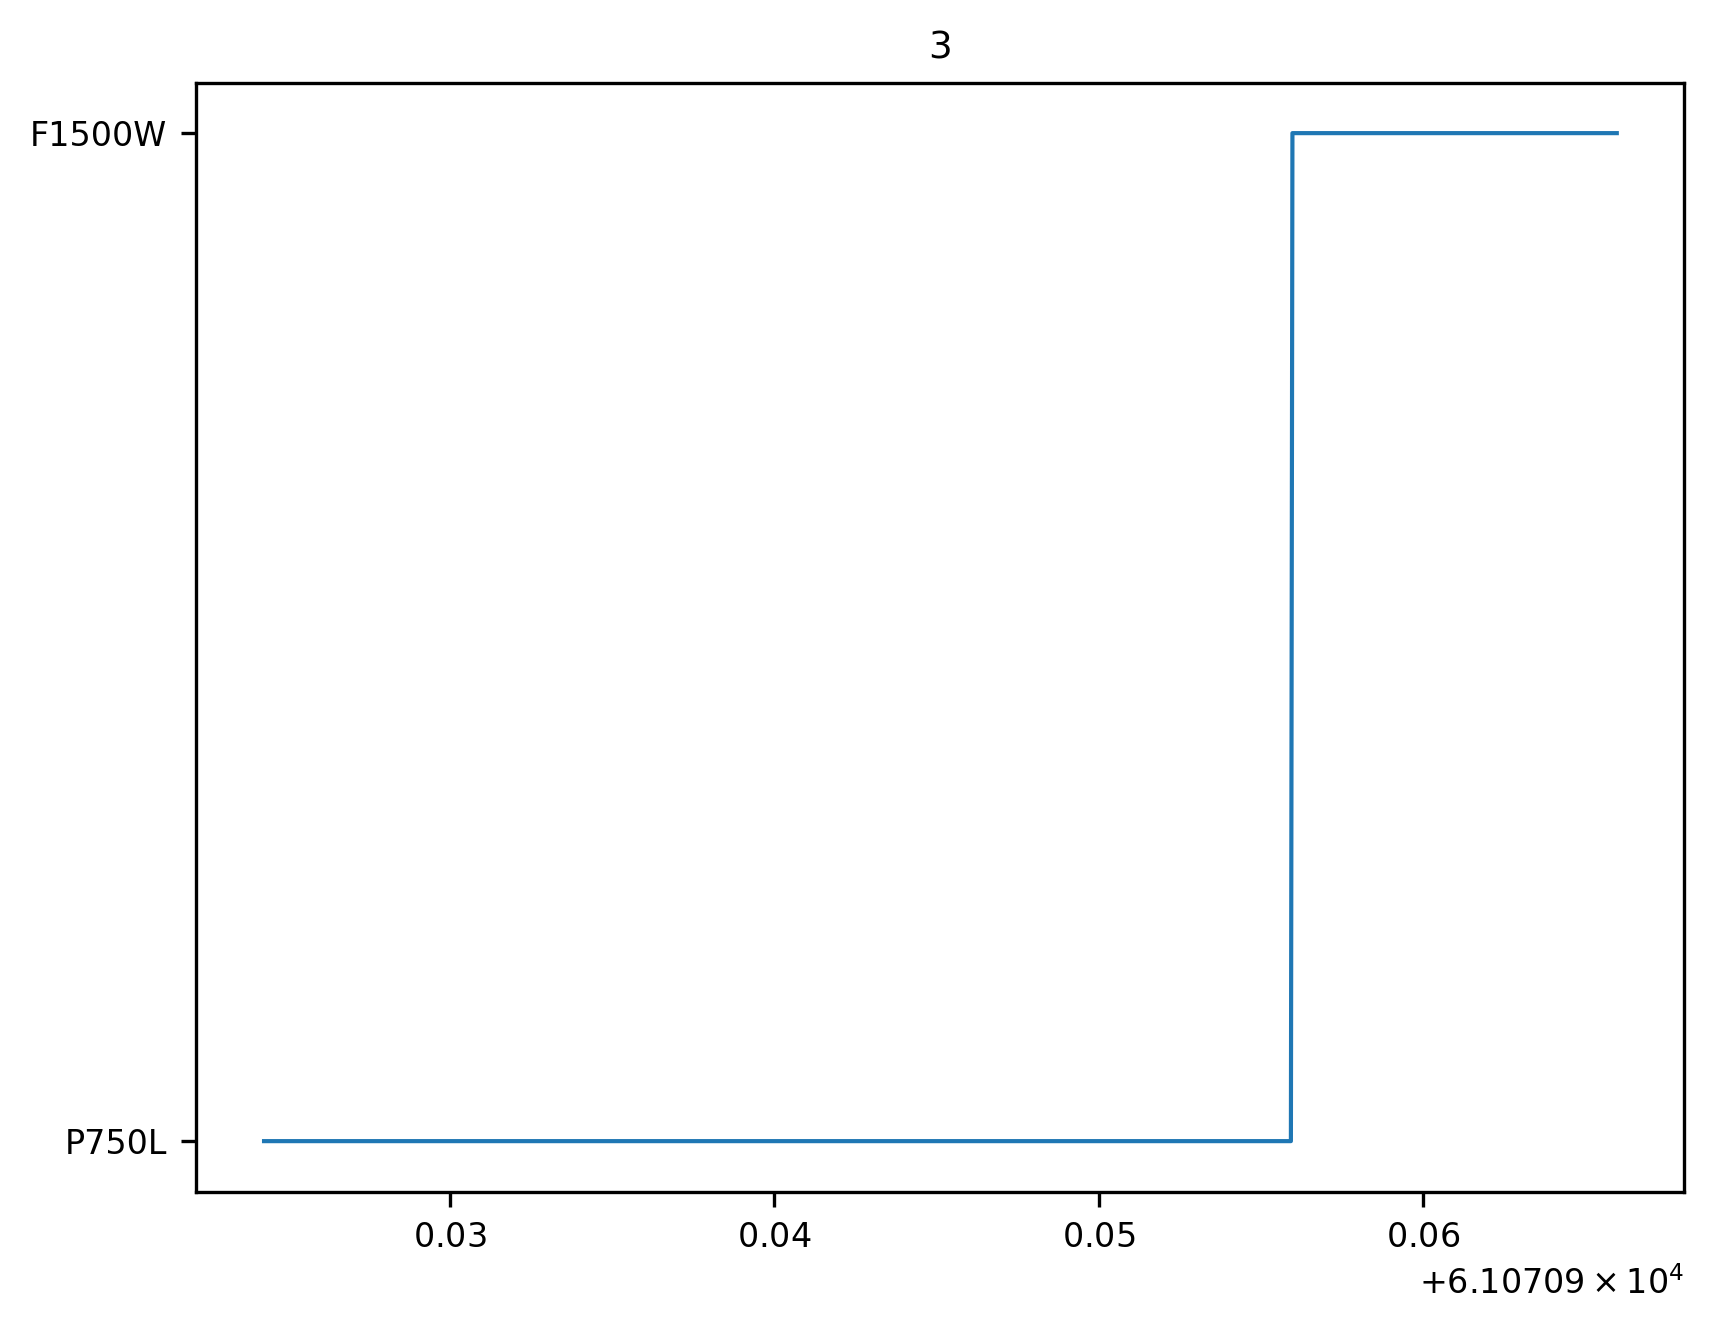

45.60 minutes
Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235004001_gs-fg_2026041134202-seg001/jw09235004001_gs-fg_2026041134202-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235004001_gs-fg_2026041134202-seg002/jw09235004001_gs-fg_2026041134202-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235004001_gs-fg_2026041134202-seg003/jw09235004001_gs-fg_2026041134202-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235004001_gs-fg_2026041134202-seg004/jw09235004001_gs-fg_2026041134202-seg004_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw

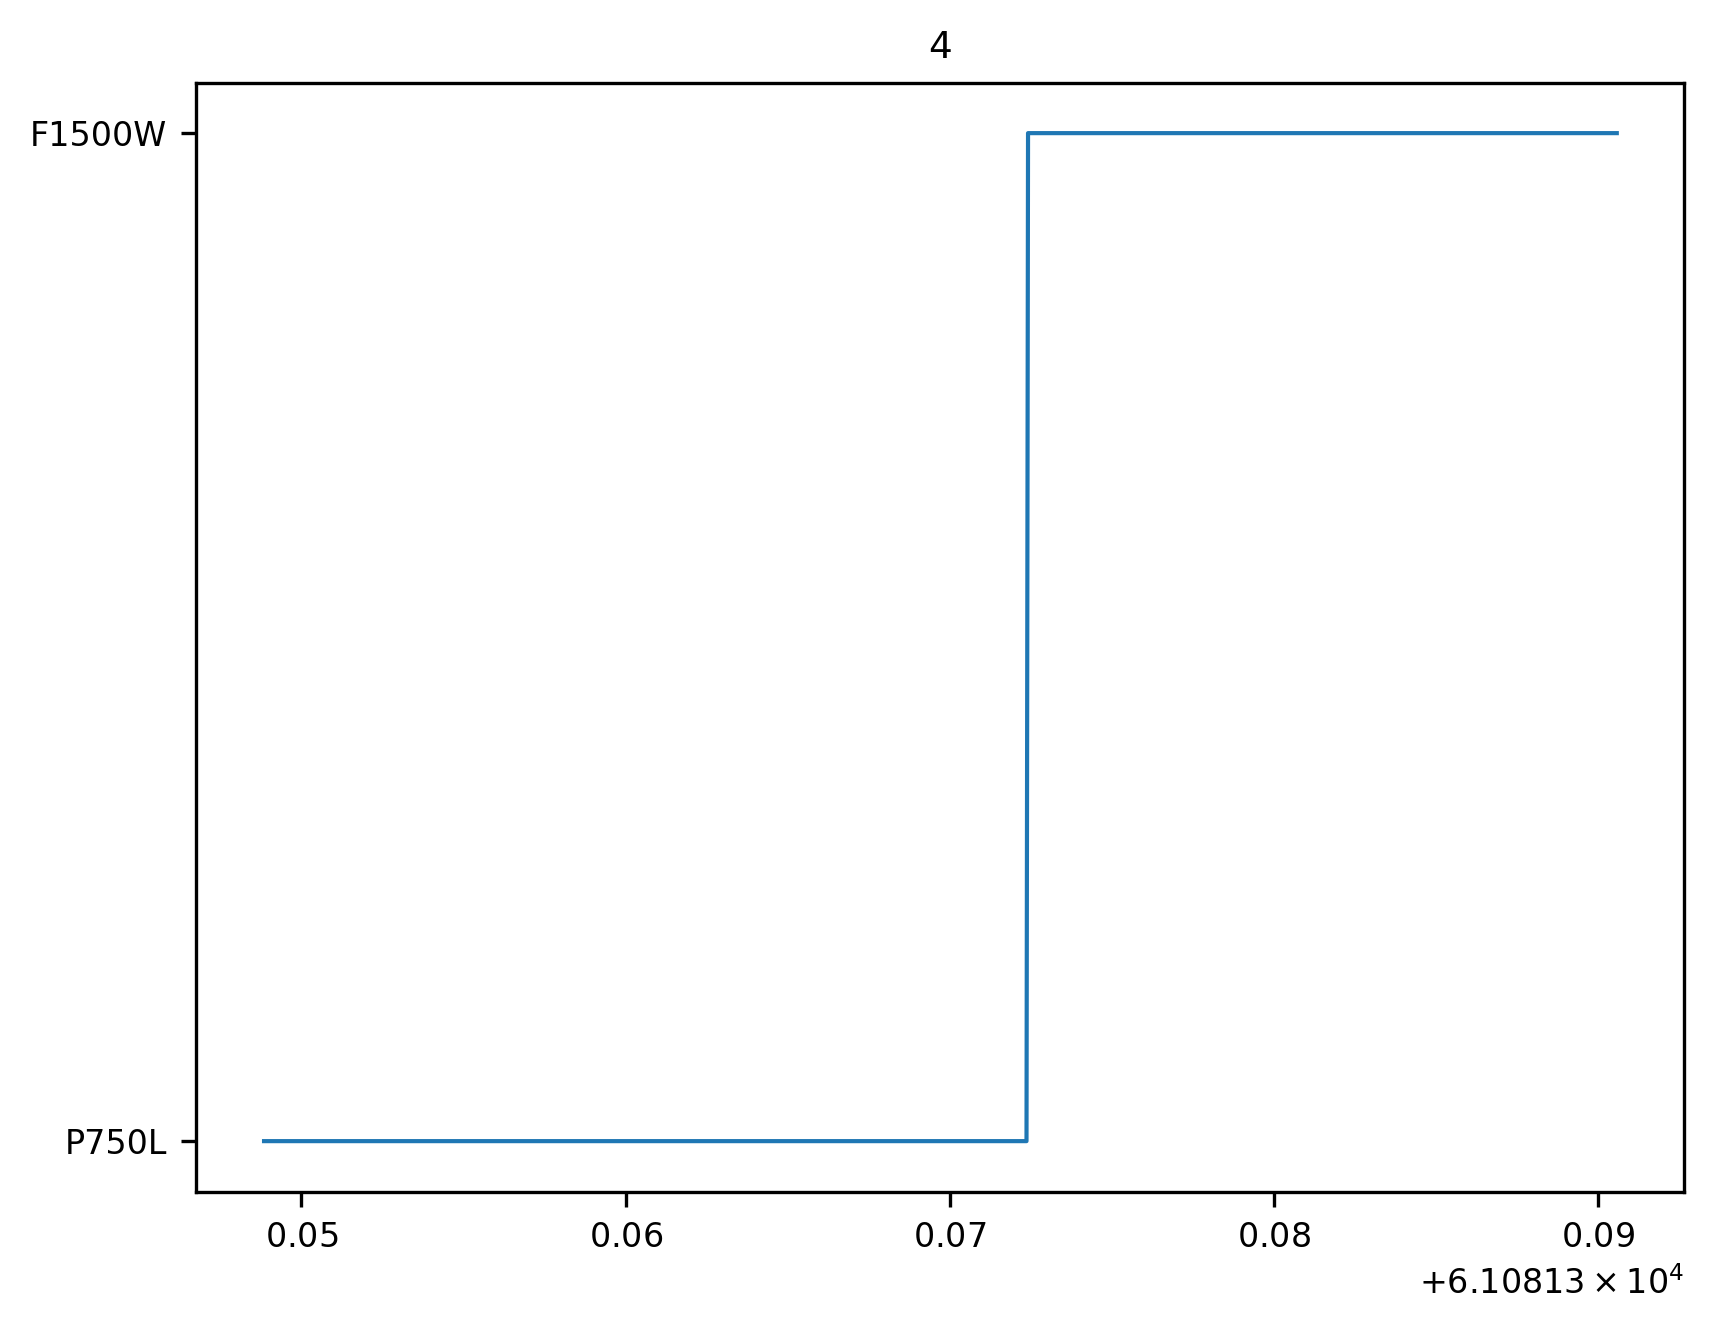

33.86 minutes


In [9]:
gj3929b_visit1 = get_p750L(9235, 1)
gj3929b_visit2 = get_p750L(9235, 2)
gj3929b_visit3 = get_p750L(9235, 3)
gj3929b_visit4 = get_p750L(9235, 4)

In [10]:
filts = ['F2100W', 'F1800W', 'F1500W', 'P750L', 'F1280W', 'F1130W', 'F1000W', 'OPAQUE', 'FND', 'F1065C', 'F2550WR', 'F1140C', 'F2550W', 'F1550C', 'F770W', 'F2300C', 'FLENS', 'F560W']

def get_mnemonics(pid, obs_num):
	spk = spelunker.load()
	try:
		spk.readfile(pid=pid, obs_num=obs_num)
	except:
		spk = spelunker.load(pid=pid, obs_num=obs_num)
	
	spk.mast_api_token = mast_api_token
		
	t_start = spk.fg_time[0] - 6/24
	t_end = spk.fg_time[0] + 2/24 # hours
	
	plt.close()
	ax0 = spk.mnemonics('IMIR_HK_FW_CUR_POS', t_start, t_end)

	line = ax0.lines[0]
	filt_x_data = line.get_xdata()
	filt_name_y_data = line.get_ydata()
	filt_y_data = [filts.index(f) for f in filt_name_y_data]

	plt.close()
	
	def get_quaternion(ind):
		ax0 = spk.mnemonics(f'SA_ZATTEST{ind}', t_start, t_end)
		line = ax0.lines[0]
		x_data = line.get_xdata()
		y_data = line.get_ydata()
		plt.close()
		return x_data, y_data - y_data[-1]
	
	q_x, q1 = get_quaternion(1)
	_, q2 = get_quaternion(2)
	_, q3 = get_quaternion(3)
	_, q4 = get_quaternion(4)

	return filt_x_data, filt_name_y_data, filt_y_data, q_x, q1, q2, q3, q4

In [11]:
class VisitInfo:
	def __init__(self, pid, obs_num):
		self.pid = pid
		self.obs_num = obs_num
		self.filtx, self.filt, self.filty, \
			self.qx, self.q1, self.q2, self.q3, self.q4 = get_mnemonics(pid, obs_num)

		on_target = np.max([
			self.qx[np.where(self.q1 <= 1e-4)[0][0]],
			self.qx[np.where(self.q2 <= 1e-4)[0][0]],
			self.qx[np.where(self.q3 <= 1e-4)[0][0]],
			self.qx[np.where(self.q4 <= 1e-4)[0][0]]
		])
	
		on_target_filter_ind = np.where(self.filtx >= on_target)[0][0]
		on_target_f1500w_ind = np.where(self.filt[on_target_filter_ind:] == 'F1500W')[0][0] + on_target_filter_ind
		on_target_f1500w = self.filtx[on_target_f1500w_ind]
	
		self.qx = (self.qx - on_target_f1500w) * 24
		self.filtx = (self.filtx - on_target_f1500w) * 24
	
		duration = (on_target_f1500w - on_target) * 24 * 60
		self.duration = duration

		# How long on P750L
		n = np.where(self.filtx >= 0)[0][0] - 1
		while self.filt[n] == 'P750L':
			n -= 1
		self.start_P750L = self.filtx[n]
		self.duration_P750L = -self.start_P750L * 60 # minutes
		if self.duration_P750L < 0:
			self.duration_P750L = -np.min(self.filtx) * 60 # set to the start of the range we checked

gj3929b_1 = VisitInfo(9235, 1)
gj3929b_2 = VisitInfo(9235, 2)
gj3929b_3 = VisitInfo(9235, 3)
gj3929b_4 = VisitInfo(9235, 4)

Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235001001_gs-fg_2025189132123-seg001/jw09235001001_gs-fg_2025189132123-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235001001_gs-fg_2025189132123-seg002/jw09235001001_gs-fg_2025189132123-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235001001_gs-fg_2025189132123-seg003/jw09235001001_gs-fg_2025189132123-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235001001_gs-fg_2025189132123-seg004/jw09235001001_gs-fg_2025189132123-seg004_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw09235001001_gs

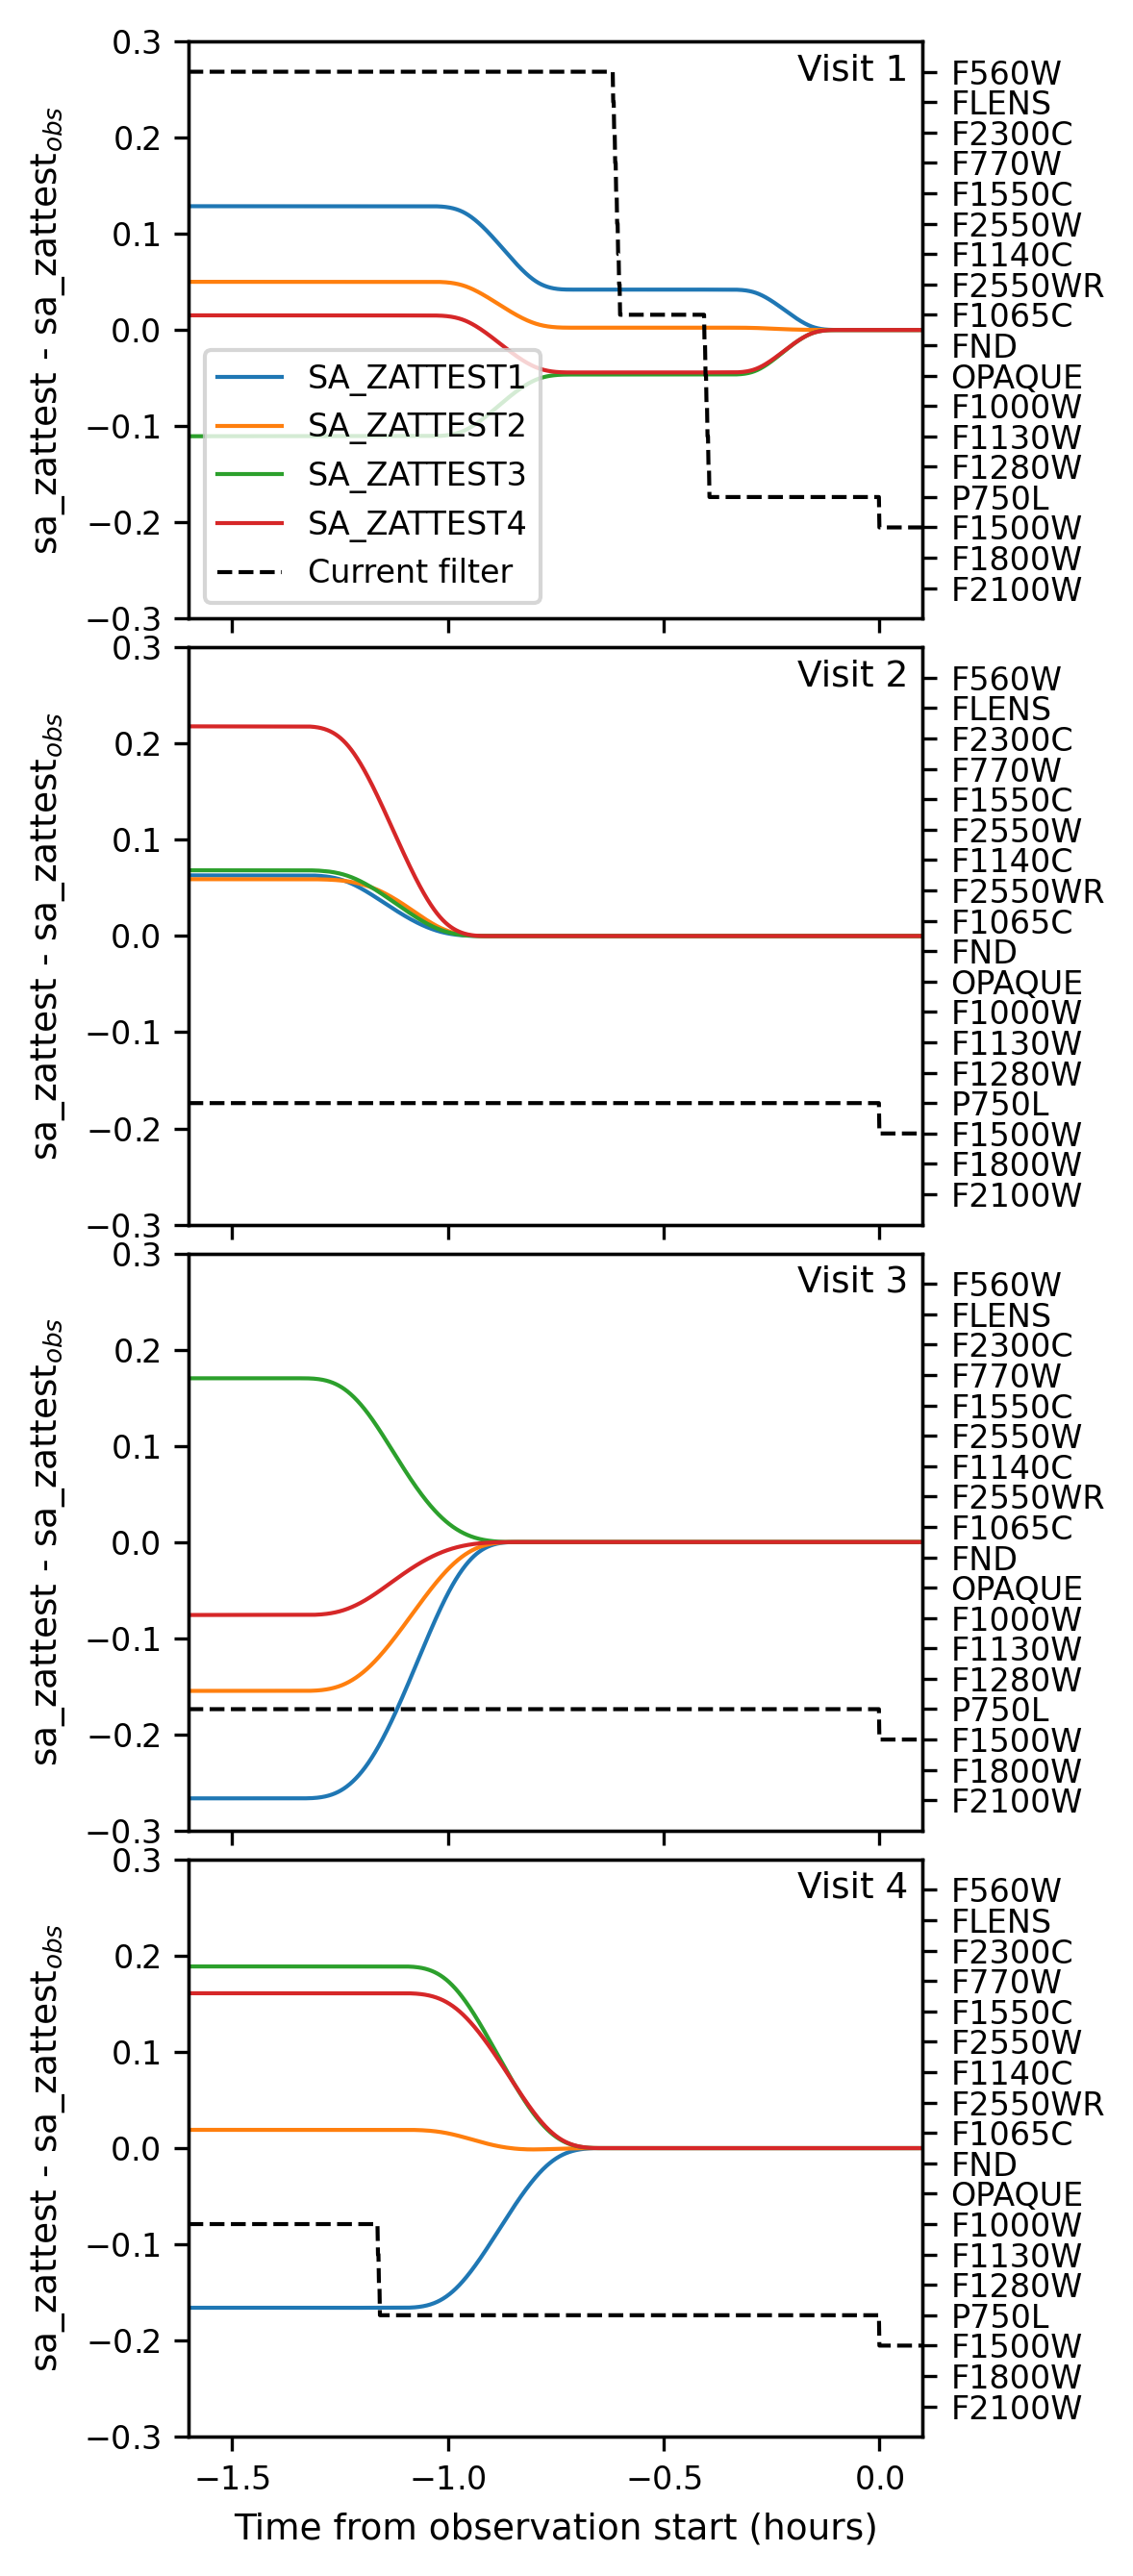

In [12]:
def plot_visit_info(ax, visit, do_legend = False):	
	ax.plot(visit.qx, visit.q1, label='SA_ZATTEST1')
	ax.plot(visit.qx, visit.q2, label='SA_ZATTEST2')
	ax.plot(visit.qx, visit.q3, label='SA_ZATTEST3')
	ax.plot(visit.qx, visit.q4, label='SA_ZATTEST4')
	ax2 = ax.twinx()
	ax2.plot(visit.filtx, visit.filty, linestyle='--', color='black', label='Current filter')
	ax2.set_yticks(np.arange(len(filts)), filts)
	ax2.set_ylim([-1, len(filts)])
	plt.xlim([-1.6, 0.1])
	plt.xticks([-1.5, -1, -0.5, 0])
	plt.xlabel("Time from observation start (hours)")
	ax.set_ylabel(r"sa_zattest - sa_zattest$_{obs}$")

	#plt.axvline(visit.start_P750L)

	if do_legend:
		lines1, labels1 = ax.get_legend_handles_labels()
		lines2, labels2 = ax2.get_legend_handles_labels()
		plt.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.close()
fig, axs = plt.subplots(4, 1, figsize=(4, 9), sharex=True, sharey=True)
plot_visit_info(axs[0], gj3929b_1, do_legend = True)
plot_visit_info(axs[1], gj3929b_2)
plot_visit_info(axs[2], gj3929b_3)
plot_visit_info(axs[3], gj3929b_4)

for i in range(4):
	axs[i].text(0.98, 0.98, f'Visit {i+1}', transform=axs[i].transAxes, ha='right', va='top')

axs[-1].set_xlabel("Time from observation start (hours)")
axs[-1].set_ylim([-0.3, 0.3])

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.savefig("figures/gj3929b_mnemonics.png", bbox_inches='tight')
plt.show()

In [13]:
hot_rocks_info = []

for i in hot_rocks_ids:
	hot_rocks_info.append(VisitInfo(3730, i))

Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730001001_gs-fg_2024072145901-seg001/jw03730001001_gs-fg_2024072145901-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730001001_gs-fg_2024072145901-seg002/jw03730001001_gs-fg_2024072145901-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730001001_gs-fg_2024072145901-seg003/jw03730001001_gs-fg_2024072145901-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730001001_gs-fg_2024072145901-seg004/jw03730001001_gs-fg_2024072145901-seg004_cal.fits']
                    filenames                    
-------------------------------------------------
jw03730001001_

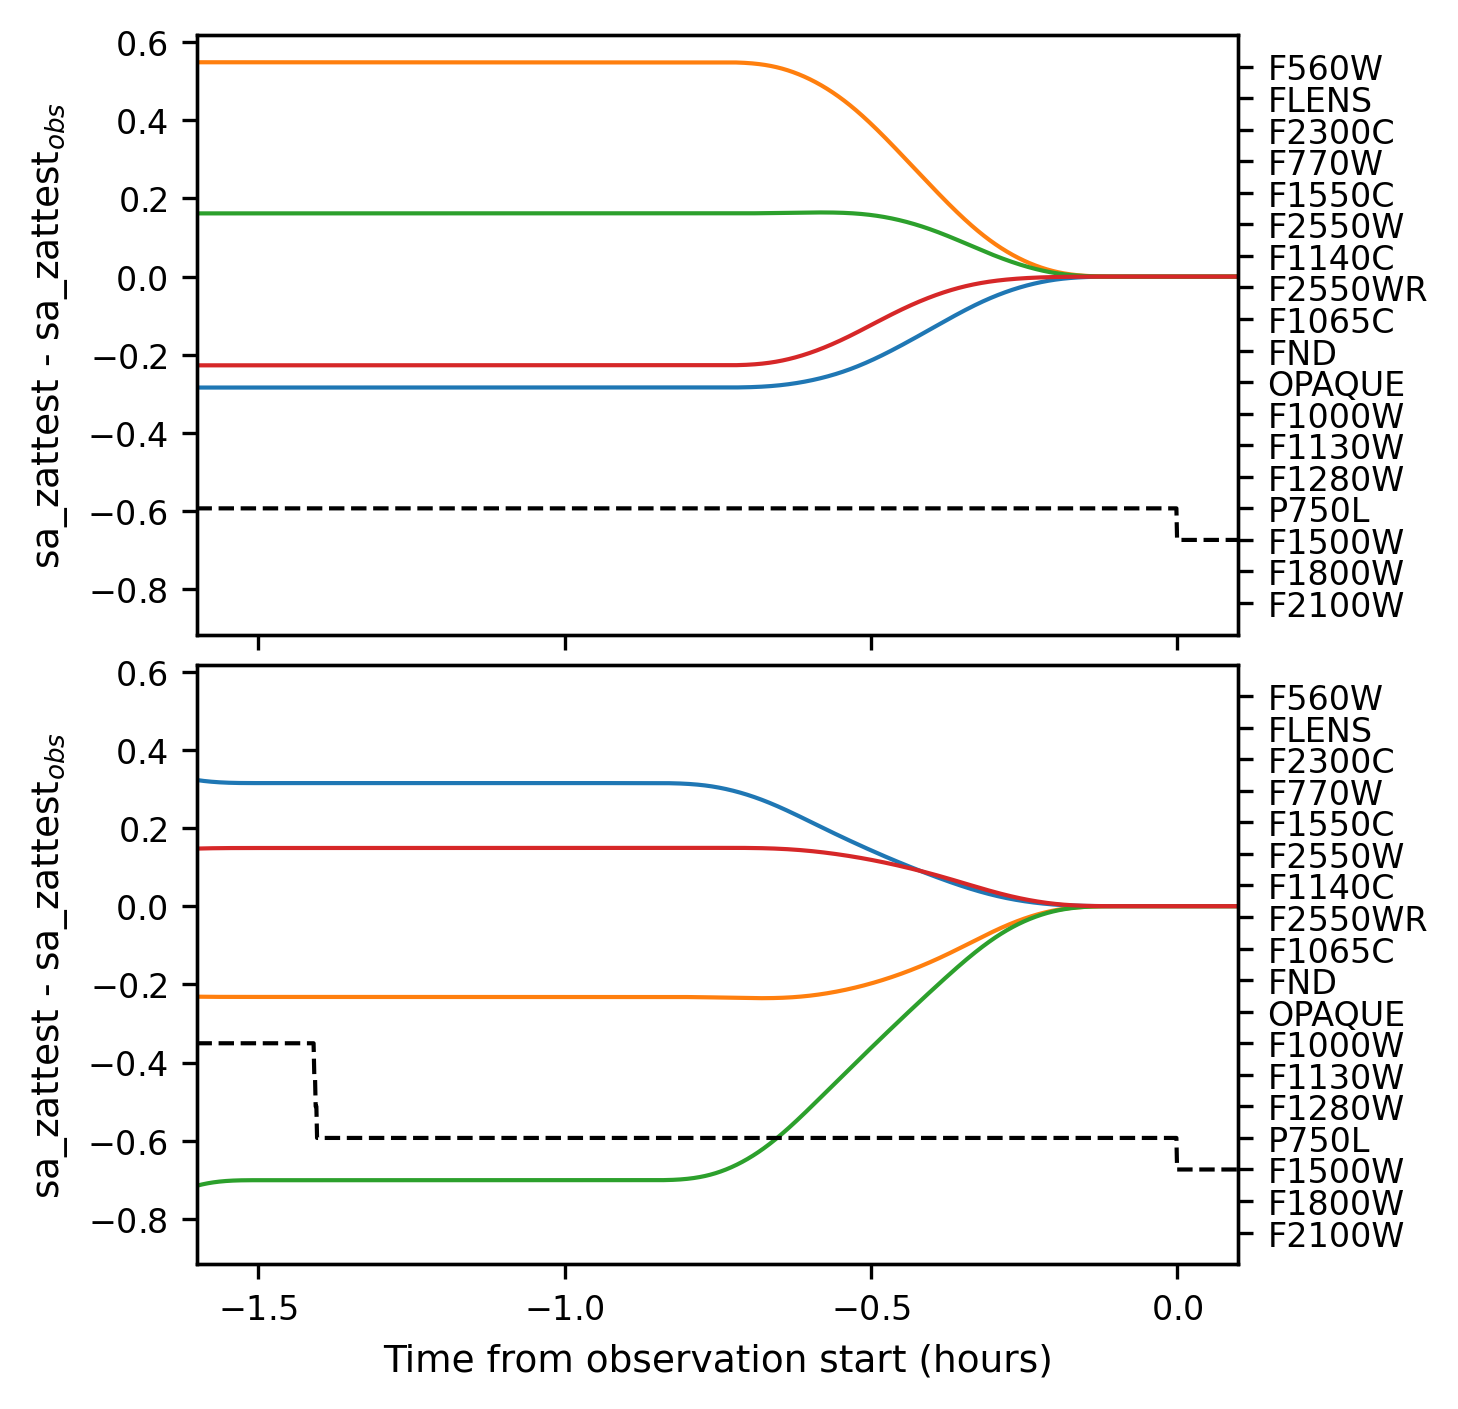

In [14]:
inds = [i for i, x in enumerate(hot_rocks_ids) if x in gj]
gj_info = np.array(hot_rocks_info)[inds][:2]

fig, axs = plt.subplots(len(gj_info), 1, figsize=(5, 0.5 + len(gj_info) * 8.5 / 4.0), sharex=True, sharey=True)
for i in range(len(gj_info)):
	plot_visit_info(axs[i], gj_info[i])
axs[-1].set_xlabel("Time from observation start (hours)")

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.savefig("figures/gj3473_mnemonics.png", bbox_inches='tight')
plt.show()

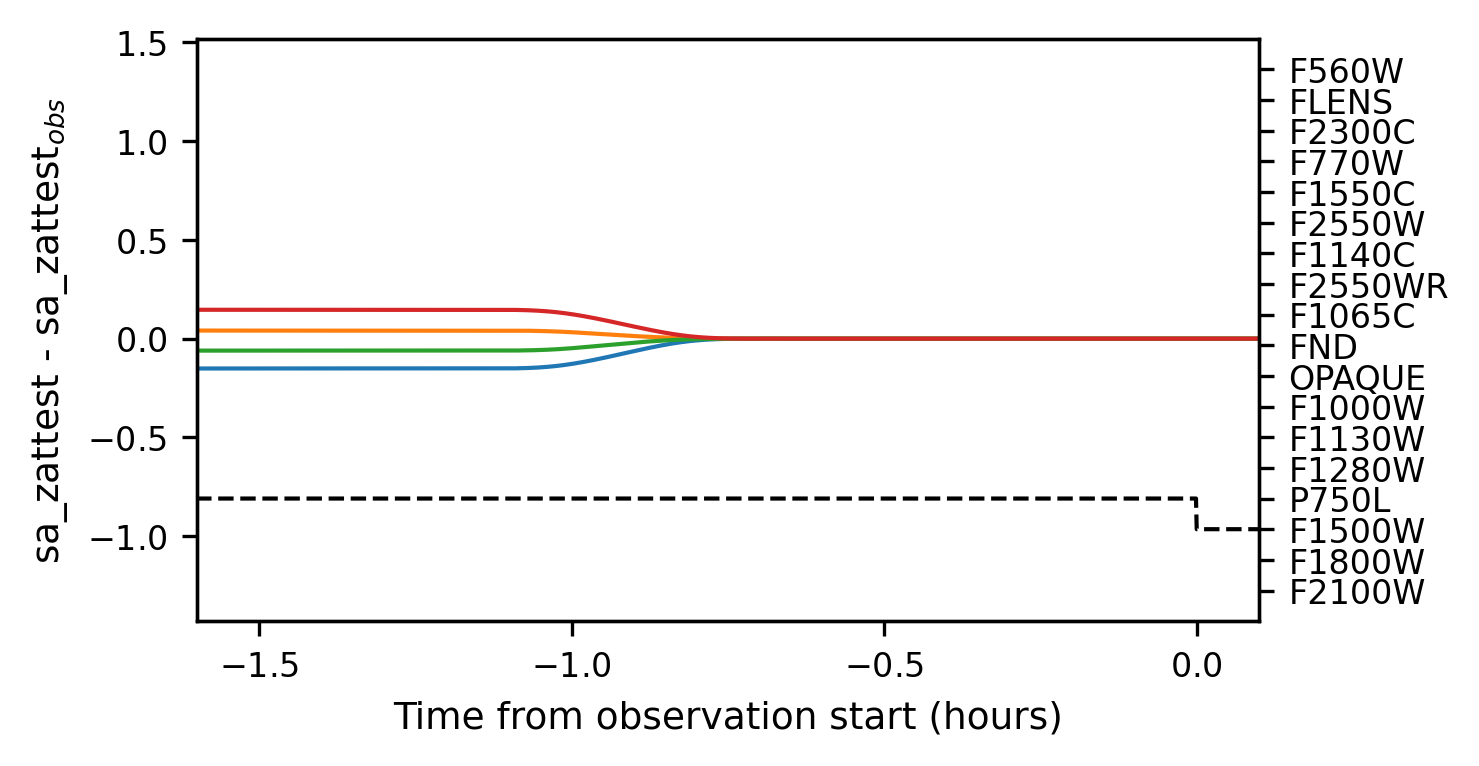

In [15]:
inds = [i for i, x in enumerate(hot_rocks_ids) if x in ltt]
ltt_info = np.array(hot_rocks_info)[inds][1:]

fig, axs = plt.subplots(len(ltt_info), 1, figsize=(5, 0.5 + len(ltt_info) * 8.5 / 4.0), sharex=True, sharey=True)
axs = [axs]
for i in range(len(ltt_info)):
	plot_visit_info(axs[i], ltt_info[i])
axs[-1].set_xlabel("Time from observation start (hours)")

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.savefig("figures/ltt3780b_mnemonics.png", bbox_inches='tight')
plt.show()

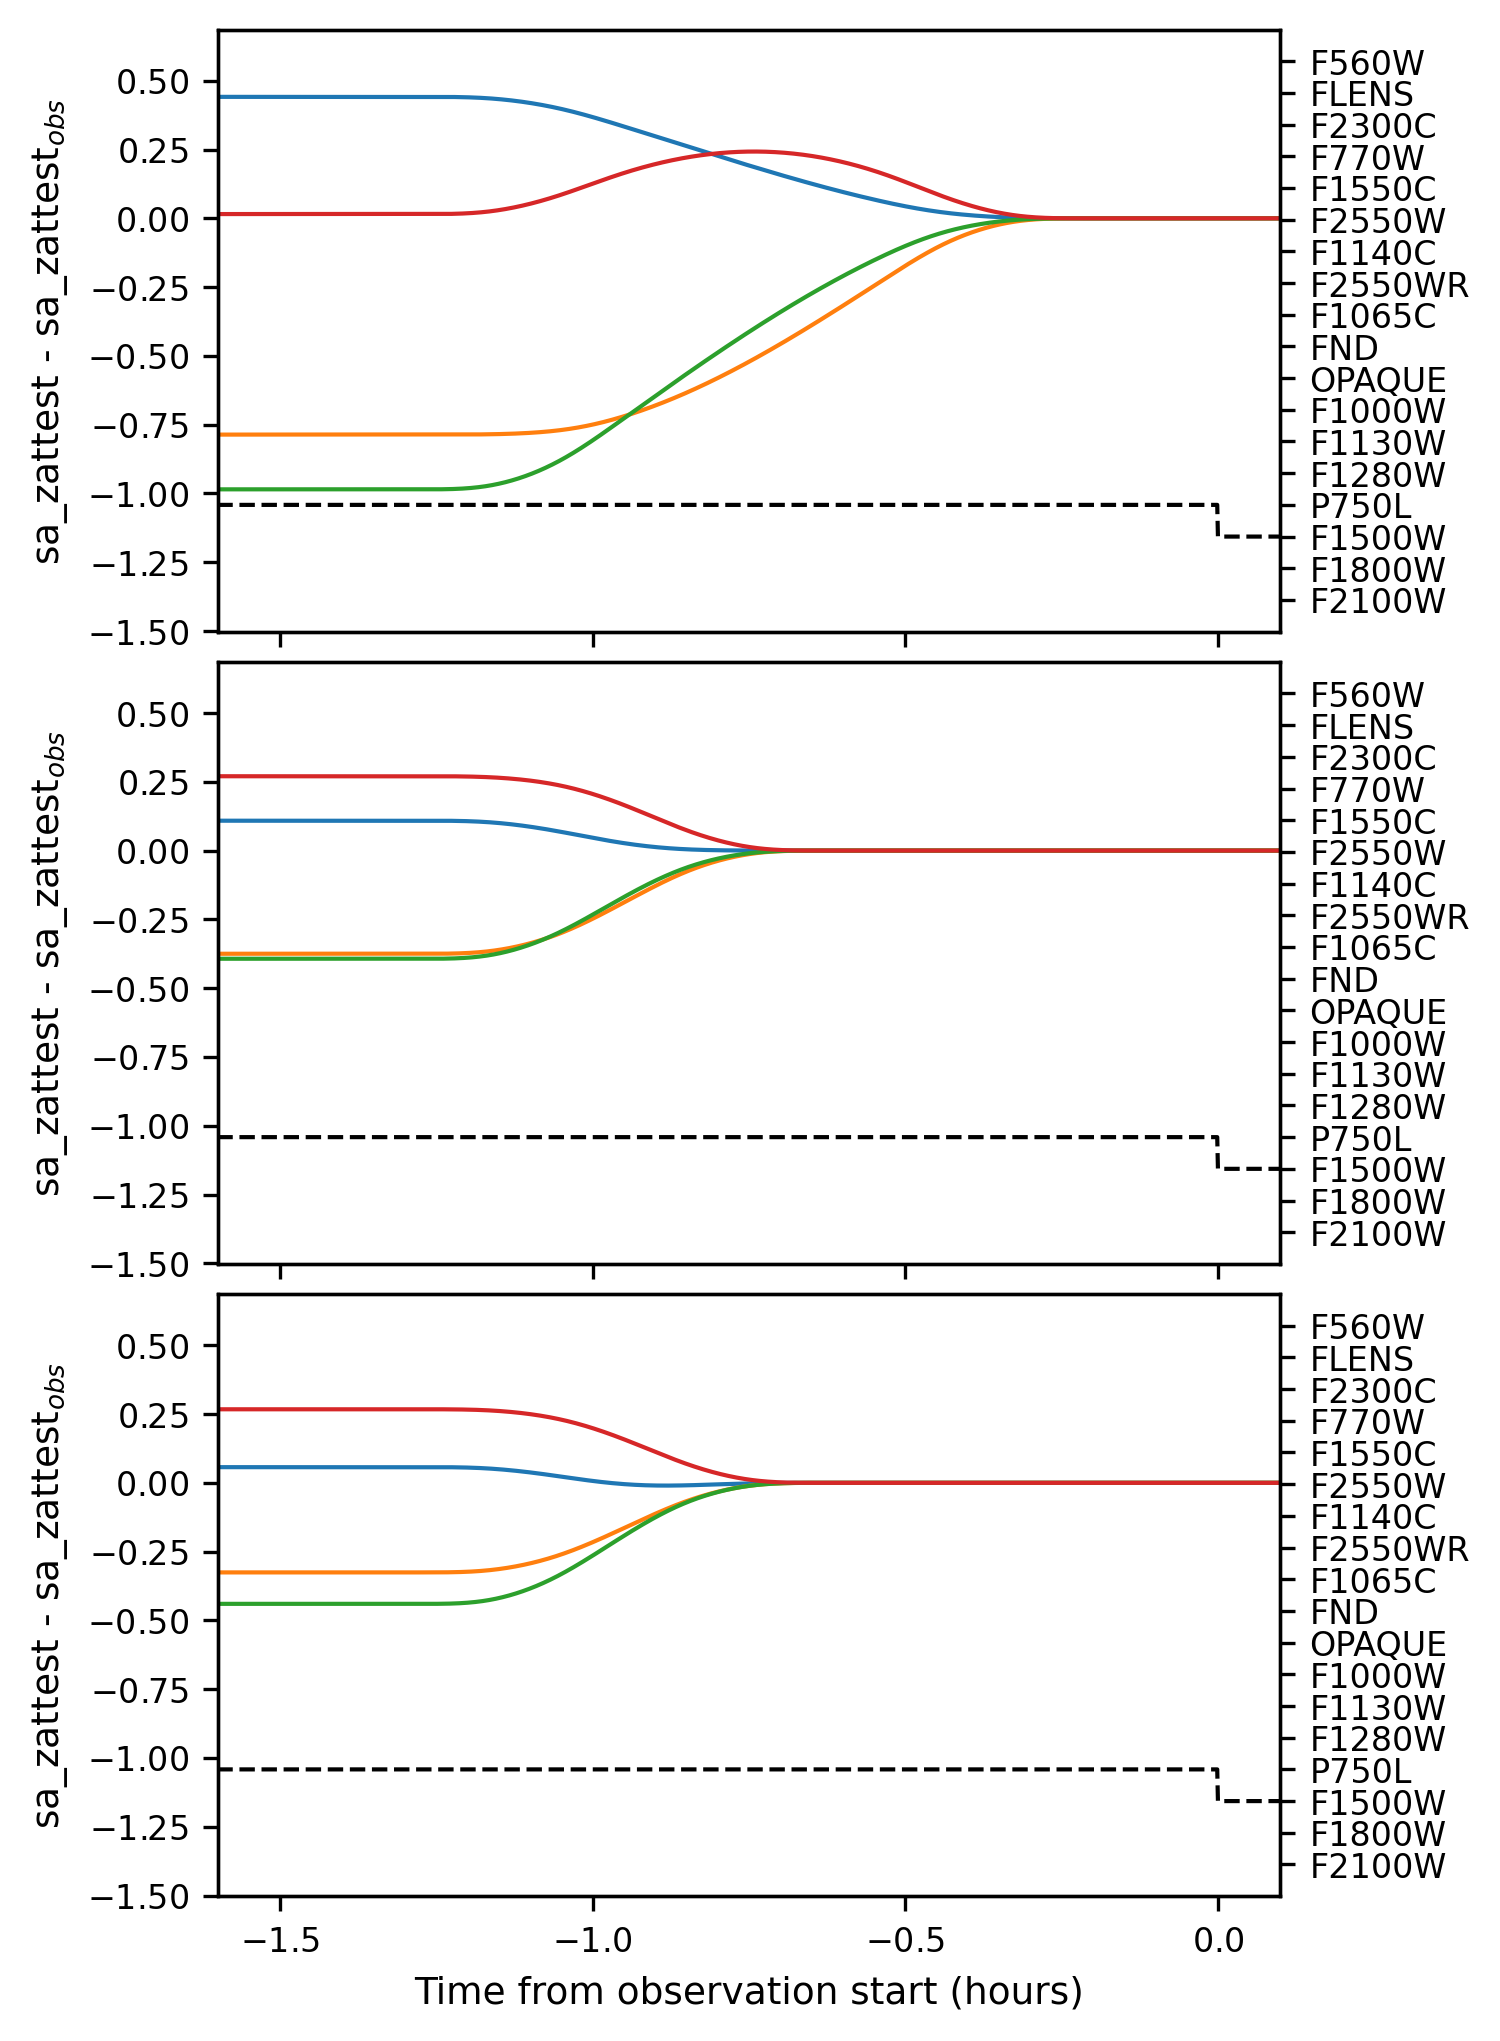

In [16]:
inds = [i for i, x in enumerate(hot_rocks_ids) if x in l231]
l231_info = np.array(hot_rocks_info)[inds][1:]

fig, axs = plt.subplots(len(l231_info), 1, figsize=(5, 0.5 + len(l231_info) * 8.5 / 4.0), sharex=True, sharey=True)
for i in range(len(l231_info)):
	plot_visit_info(axs[i], l231_info[i])
axs[-1].set_xlabel("Time from observation start (hours)")

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.savefig("figures/l231-32b_mnemonics.png", bbox_inches='tight')
plt.show()

[3 4]
[<__main__.VisitInfo object at 0x77e3164dc2d0>, <__main__.VisitInfo object at 0x77e317251250>, <__main__.VisitInfo object at 0x77e310614b50>, <__main__.VisitInfo object at 0x77e315d2f750>, <__main__.VisitInfo object at 0x77e316505c10>, <__main__.VisitInfo object at 0x77e3107bd550>, <__main__.VisitInfo object at 0x77e3133a9510>, <__main__.VisitInfo object at 0x77e3172471d0>, <__main__.VisitInfo object at 0x77e3126a7e10>, <__main__.VisitInfo object at 0x77e312f02150>]
[44.72101667197421]
[-0.0502588865890738]
[5 6 7 8]
[<__main__.VisitInfo object at 0x77e3164dc2d0>, <__main__.VisitInfo object at 0x77e317251250>, <__main__.VisitInfo object at 0x77e310614b50>, <__main__.VisitInfo object at 0x77e315d2f750>, <__main__.VisitInfo object at 0x77e316505c10>, <__main__.VisitInfo object at 0x77e3107bd550>, <__main__.VisitInfo object at 0x77e3133a9510>, <__main__.VisitInfo object at 0x77e3172471d0>, <__main__.VisitInfo object at 0x77e3126a7e10>, <__main__.VisitInfo object at 0x77e312f02150>]


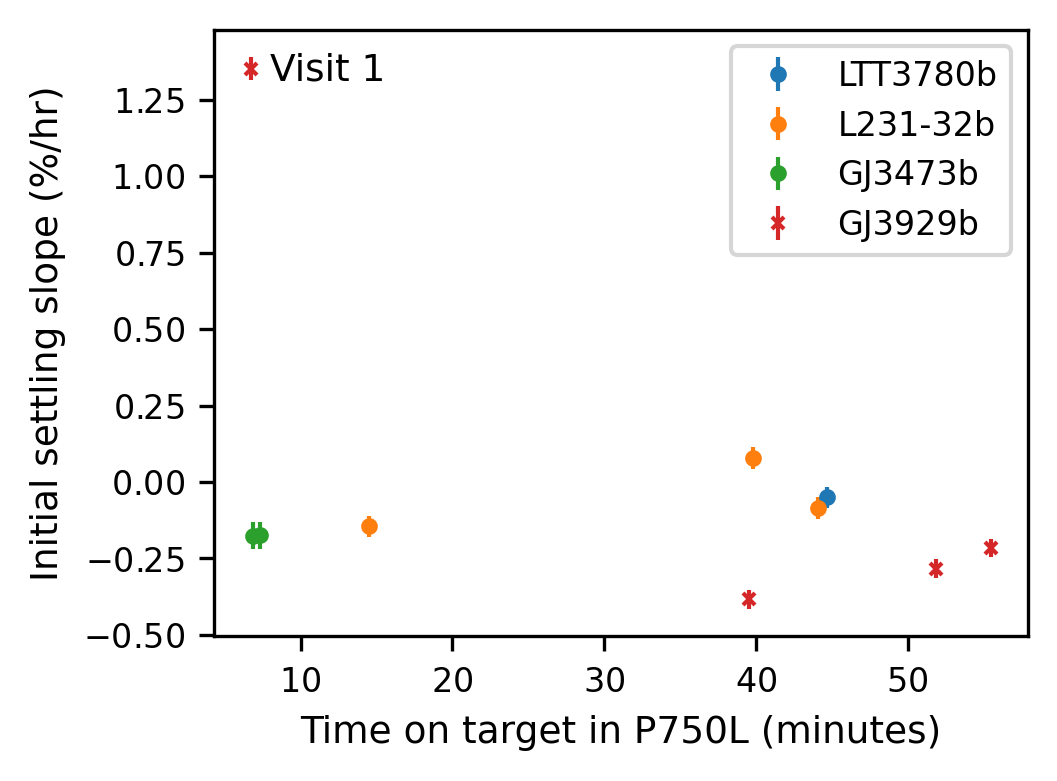

In [17]:
durations = [
	gj3929b_1.duration, 
	gj3929b_2.duration, 
	gj3929b_3.duration, 
	gj3929b_4.duration
]

slopes = [
	gj3929b_visit1_slope,
	gj3929b_visit2_slope,
	gj3929b_visit3_slope,
	gj3929b_visit4_slope,
]

y = [s.nominal_value for s in slopes]
yerr = np.array([s.std_dev for s in slopes]) 

plt.figure(figsize=single_column)

def plot_group(match, name):
	inds = np.array([i for i, x in enumerate(hot_rocks_ids) if x in match])
	print(inds)
	print(hot_rocks_info)
	hr_x = [d.duration for i, d in enumerate(np.array(hot_rocks_info)[inds]) if hot_rocks_slopes[inds][i] != 0]
	print(hr_x)
	hr_y = [s.nominal_value for s in hot_rocks_slopes[inds] if s != 0]
	hr_yerr = np.array([s.std_dev for s in hot_rocks_slopes[inds] if s != 0]) 
	print(hr_y)
	plt.errorbar(hr_x, hr_y, hr_yerr, linestyle='', marker='.', label=name)
plot_group(ltt, 'LTT3780b')
plot_group(l231, 'L231-32b')
plot_group(gj, 'GJ3473b')

plt.annotate("Visit 1", (durations[0], y[0]), textcoords = 'offset fontsize', xytext=(0.5, -0.3))

plt.errorbar(durations, y, yerr, linestyle='', marker='x', ms=3, label='GJ3929b')
plt.xlabel("Time on target in P750L (minutes)")
plt.ylabel("Initial settling slope (%/hr)")
plt.legend()
plt.savefig("figures/detector settling slope vs time on target.png", bbox_inches='tight')
plt.savefig("figures/detector settling slope vs time on target.pdf", bbox_inches='tight')
plt.show()

[0.39480861 6.82893556 1.88984722 1.15825667]
[3 4]
[<__main__.VisitInfo object at 0x77e3164dc2d0>, <__main__.VisitInfo object at 0x77e317251250>, <__main__.VisitInfo object at 0x77e310614b50>, <__main__.VisitInfo object at 0x77e315d2f750>, <__main__.VisitInfo object at 0x77e316505c10>, <__main__.VisitInfo object at 0x77e3107bd550>, <__main__.VisitInfo object at 0x77e3133a9510>, <__main__.VisitInfo object at 0x77e3172471d0>, <__main__.VisitInfo object at 0x77e3126a7e10>, <__main__.VisitInfo object at 0x77e312f02150>]
[1.6804961112211458]
[-0.0502588865890738]
[5 6 7 8]
[<__main__.VisitInfo object at 0x77e3164dc2d0>, <__main__.VisitInfo object at 0x77e317251250>, <__main__.VisitInfo object at 0x77e310614b50>, <__main__.VisitInfo object at 0x77e315d2f750>, <__main__.VisitInfo object at 0x77e316505c10>, <__main__.VisitInfo object at 0x77e3107bd550>, <__main__.VisitInfo object at 0x77e3133a9510>, <__main__.VisitInfo object at 0x77e3172471d0>, <__main__.VisitInfo object at 0x77e3126a7e10>, 

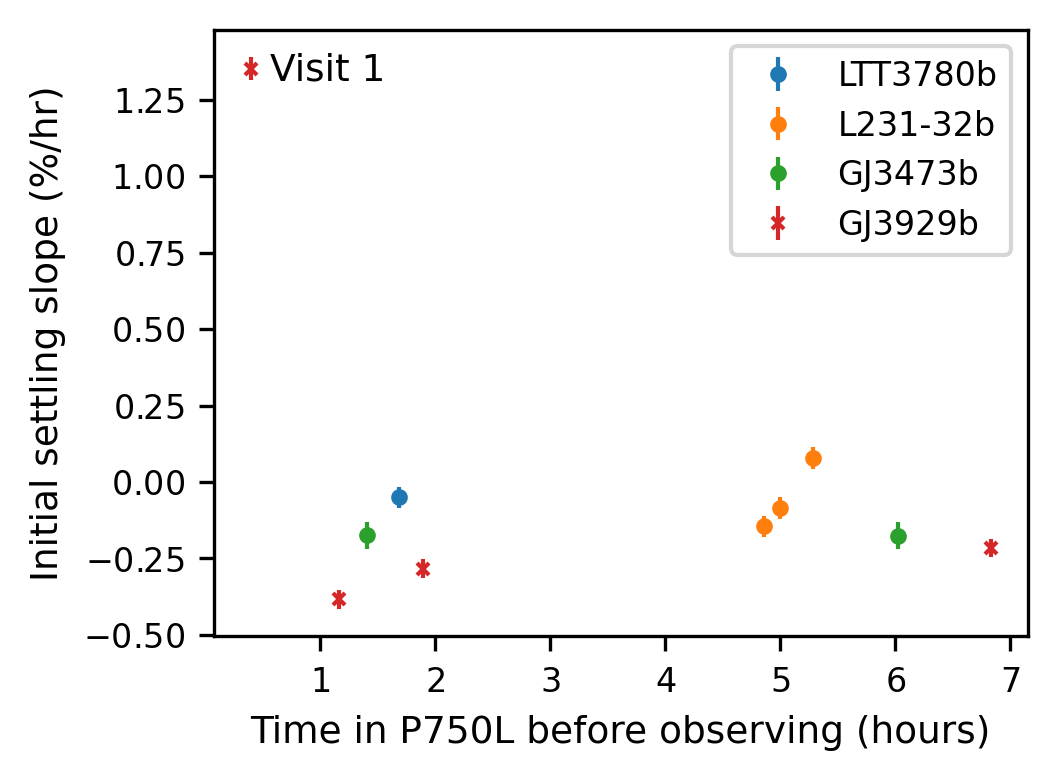

In [18]:
durations = np.array([
	gj3929b_1.duration_P750L, 
	gj3929b_2.duration_P750L, 
	gj3929b_3.duration_P750L, 
	gj3929b_4.duration_P750L
]) / 60

slopes = [
	gj3929b_visit1_slope,
	gj3929b_visit2_slope,
	gj3929b_visit3_slope,
	gj3929b_visit4_slope,
]

print(durations)

y = [s.nominal_value for s in slopes]
yerr = np.array([s.std_dev for s in slopes]) 

plt.figure(figsize=single_column)

def plot_group(match, name):
	inds = np.array([i for i, x in enumerate(hot_rocks_ids) if x in match])
	print(inds)
	print(hot_rocks_info)
	hr_x = [d.duration_P750L/60 for i, d in enumerate(np.array(hot_rocks_info)[inds]) if hot_rocks_slopes[inds][i] != 0]
	print(hr_x)
	hr_y = [s.nominal_value for s in hot_rocks_slopes[inds] if s != 0]
	hr_yerr = np.array([s.std_dev for s in hot_rocks_slopes[inds] if s != 0]) 
	print(hr_y)
	plt.errorbar(hr_x, hr_y, hr_yerr, linestyle='', marker='.', label=name)
plot_group(ltt, 'LTT3780b')
plot_group(l231, 'L231-32b')
plot_group(gj, 'GJ3473b')

plt.annotate("Visit 1", (durations[0], y[0]), textcoords = 'offset fontsize', xytext=(0.5, -0.3))

plt.errorbar(durations, y, yerr, linestyle='', marker='x', ms=3, label='GJ3929b')
plt.xlabel("Time in P750L before observing (hours)")
plt.ylabel("Initial settling slope (%/hr)")
plt.legend()
plt.savefig("figures/detector settling slope vs time on P750L.png", bbox_inches='tight')
plt.savefig("figures/detector settling slope vs time on P750L.pdf", bbox_inches='tight')
plt.show()

In [19]:
lhs1478b_1 = VisitInfo(3730, 12)
lhs1478b_2 = VisitInfo(3730, 13)

Current working directory for spelunker: /mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs

['/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730012001_gs-fg_2024020083819-seg001/jw03730012001_gs-fg_2024020083819-seg001_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730012001_gs-fg_2024020083819-seg002/jw03730012001_gs-fg_2024020083819-seg002_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730012001_gs-fg_2024020083819-seg003/jw03730012001_gs-fg_2024020083819-seg003_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730012001_gs-fg_2024020083819-seg004/jw03730012001_gs-fg_2024020083819-seg004_cal.fits', '/mnt/c/Users/nicho/Research/GitHub/erebus/connors_et_al_2026/spelunker_outputs/mastDownload/JWST/jw03730012001_gs

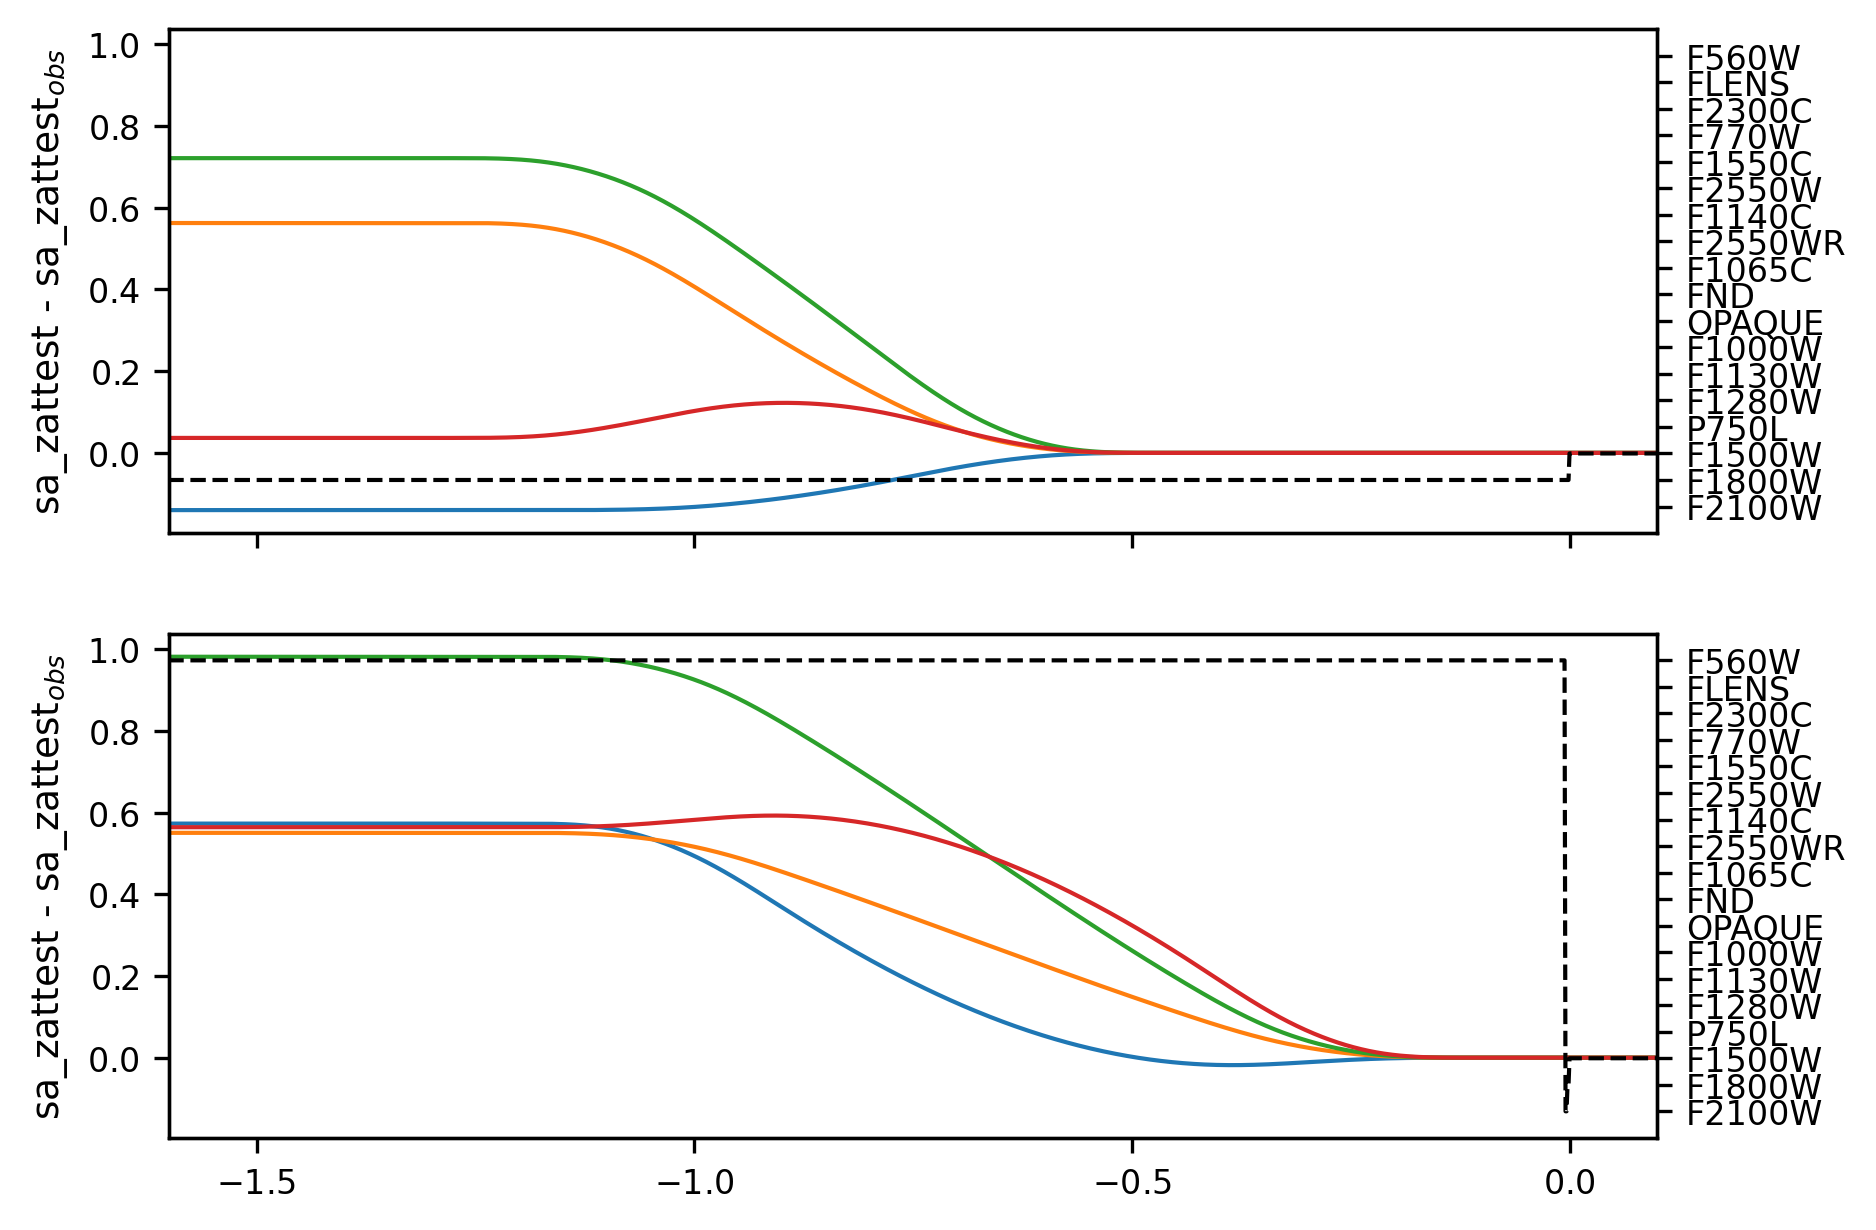

29.860233329236507
8.33064999198541


In [20]:
fig, axs = plt.subplots(2, 1, sharex=True, sharey=True)
plot_visit_info(axs[0], lhs1478b_1)
plot_visit_info(axs[1], lhs1478b_2)
plt.xlabel("Time from observation start (hours)")
plt.show()

print(lhs1478b_1.duration)
print(lhs1478b_2.duration)

In [21]:
'''
all_hot_rocks = [1, 2, 29, 4, 23, 27, 28, 6, 24, 7, 25, 8, 
				 26, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
				 20, 21, 22]

all_hot_rocks_info = []
for obs_num in all_hot_rocks:
	all_hot_rocks_info.append(VisitInfo(3730, obs_num))
'''

'\nall_hot_rocks = [1, 2, 29, 4, 23, 27, 28, 6, 24, 7, 25, 8, \n\t\t\t\t 26, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,\n\t\t\t\t 20, 21, 22]\n\nall_hot_rocks_info = []\nfor obs_num in all_hot_rocks:\n\tall_hot_rocks_info.append(VisitInfo(3730, obs_num))\n'

In [22]:
'''
for i in range(len(all_hot_rocks_info)):
	fig, ax = plt.subplots(1,1)
	plot_visit_info(ax, all_hot_rocks_info[i])
	plt.title(f"Obs num: {all_hot_rocks[i]}")
	plt.show()
'''

'\nfor i in range(len(all_hot_rocks_info)):\n\tfig, ax = plt.subplots(1,1)\n\tplot_visit_info(ax, all_hot_rocks_info[i])\n\tplt.title(f"Obs num: {all_hot_rocks[i]}")\n\tplt.show()\n'